This notebook uses the pretrained Booster surrogate models to sample the prior predictive distribution

# Setup

In [1]:
using Pkg
Pkg.activate("UQ_cuda13") #replace with your own environment or disable as appropriate
using CUDA
CUDA.versioninfo()
CUDA.devices()
CUDA.device()

  Activating project at `~/workspace/Storage/ckelly/persistent/UQ/Genesis/prior_predictive_sample_surrogate/UQ_cuda13`


CUDA toolchain: 
- runtime 12.9, artifact installation
- driver 535.129.3 for 12.2
- compiler 12.9

CUDA libraries: 
- CUBLAS: 12.9.1
- CURAND: 10.3.10
- CUFFT: 11.4.1
- CUSOLVER: 11.7.5
- CUSPARSE: 12.5.10
- CUPTI: 2025.2.1 (API 12.9.1)
- NVML: 12.0.0+535.129.3

Julia packages: 
- CUDA: 5.11.0
- GPUArrays: 11.4.1
- GPUCompiler: 1.9.1
- KernelAbstractions: 0.9.41
- CUDA_Driver_jll: 13.2.0+0
- CUDA_Compiler_jll: 0.4.2+0
- CUDA_Runtime_jll: 0.21.0+0

Toolchain:
- Julia: 1.11.9
- LLVM: 16.0.6

Preferences:
- CUDA_Runtime_jll.version: 12.9

1 device:
  0: Tesla P100-PCIE-16GB (sm_60, 15.893 GiB / 16.000 GiB available)


CuDevice(0): Tesla P100-PCIE-16GB

In [2]:
using cuDNN
using JSON
using Statistics
using Serialization
using NamedArrays
using Turing
using PDMats
using LinearAlgebra
using ReverseDiff
using Random
using Plots
using cuDNN
using Flux
using Pandas

In [3]:
using OrderedCollections
using JLD2

# Set up surrogate

Initialize the parameter mapping for the input features

In [4]:
#x-correctors
cx_l = ["DHCA2","DHCA4","DHCA6","DHCA8","DHCB2","DHCB4","DHCB6","DHCB8","DHCC2","DHCC4","DHCC6","DHCC8",
    "DHCD2","DHCD4","DHCD6","DHCD8","DHCE2","DHCE4","DHCE6","DHCE8","DHCF2","DHCF4","DHCF6","DHCF8"] #why was D6 not in this list from Lucy?

#y-correctors
cy_l = [ "DVCA1", "DVCA3", "DVCA5", "DVCA7", "DVCB1", "DVCB3", "DVCB5", "DVCB7", "DVCC1", "DVCC3", "DVCC5",
"DVCC7", "DVCD1", "DVCD3", "DVCD5", "DVCD7", "DVCE1", "DVCE3", "DVCE5", "DVCE7", "DVCF1", "DVCF3", "DVCF5", "DVCF7"]

#static magnet currents
currents = ["idipo","iqhc", "iqvc", "ish", "isv"]

#x-vars (the multiplicative transfer function weights in the x-plane)
var_x_names = [string("trans-var-x-",i) for i in 1:24]
#y-vars
var_y_names = [string("trans-var-y-",i) for i in 1:24]

#put them all together in the right order (correctors first!)
hplane="x"
hall_currents = vcat(cx_l, currents) 
hdimnames = deepcopy(hall_currents) #this is the dimension ordering used for the surrogate model

vplane="y"
vall_currents = vcat(cy_l, currents) 
vdimnames = deepcopy(vall_currents) 

for i in 1:24
    push!(hdimnames, var_x_names[i])
    push!(vdimnames, var_x_names[i])
end
#y-vars
for i in 1:24
    push!(hdimnames, var_y_names[i])
    push!(vdimnames, var_y_names[i])
end

println("H-Dimnames: ",hdimnames, " size ",length(hdimnames))
println("V-Dimnames: ",vdimnames, " size ",length(vdimnames))

H-Dimnames: ["DHCA2", "DHCA4", "DHCA6", "DHCA8", "DHCB2", "DHCB4", "DHCB6", "DHCB8", "DHCC2", "DHCC4", "DHCC6", "DHCC8", "DHCD2", "DHCD4", "DHCD6", "DHCD8", "DHCE2", "DHCE4", "DHCE6", "DHCE8", "DHCF2", "DHCF4", "DHCF6", "DHCF8", "idipo", "iqhc", "iqvc", "ish", "isv", "trans-var-x-1", "trans-var-x-2", "trans-var-x-3", "trans-var-x-4", "trans-var-x-5", "trans-var-x-6", "trans-var-x-7", "trans-var-x-8", "trans-var-x-9", "trans-var-x-10", "trans-var-x-11", "trans-var-x-12", "trans-var-x-13", "trans-var-x-14", "trans-var-x-15", "trans-var-x-16", "trans-var-x-17", "trans-var-x-18", "trans-var-x-19", "trans-var-x-20", "trans-var-x-21", "trans-var-x-22", "trans-var-x-23", "trans-var-x-24", "trans-var-y-1", "trans-var-y-2", "trans-var-y-3", "trans-var-y-4", "trans-var-y-5", "trans-var-y-6", "trans-var-y-7", "trans-var-y-8", "trans-var-y-9", "trans-var-y-10", "trans-var-y-11", "trans-var-y-12", "trans-var-y-13", "trans-var-y-14", "trans-var-y-15", "trans-var-y-16", "trans-var-y-17", "trans-var-y

In [5]:
hsurrogate = deserialize("surrogate_horizontal.ser")
vsurrogate = deserialize("surrogate_vertical.ser")

hmodel_gpu = hsurrogate[1] |> gpu
vmodel_gpu = vsurrogate[1] |> gpu

Chain(
  Dense(77 => 400, relu),               # 31_200 parameters
  SkipConnection(
    Dense(400 => 400, relu),            # 160_400 parameters
    +,
  ),
  SkipConnection(
    Dense(400 => 400, relu),            # 160_400 parameters
    +,
  ),
  Dense(400 => 18),                     # 7_218 parameters
)                   # Total: 8 arrays, 359_218 parameters, 1.258 KiB.

Note that hsurrogate[2], vsurrogate[2] are the mean and std of the model *inputs*, required for normalization

Similarly, hsurrogate[3], vsurrogate[3] same for the model *outputs*

In [6]:
#Functions for normalizing and unnormalizing model inputs
function normalize_fast(mat::AbstractMatrix, mu_std::Vector{ Tuple{Float64,Float64} })
    tmp = [ [ (xx-mu_std[i][1])/mu_std[i][2] for xx in view(mat,i,:) ] for i in 1:size(mat,1) ]
    return reduce(vcat,transpose.(tmp))
end
function unnormalize_fast(mat::AbstractMatrix, mu_std::Vector{ Tuple{Float64,Float64} })
    tmp = [ [ xx*mu_std[i][2] + mu_std[i][1] for xx in view(mat,i,:) ] for i in 1:size(mat,1) ]
    return reduce(vcat,transpose.(tmp))
end

unnormalize_fast (generic function with 1 method)

In [7]:
using Zygote

#Run the surrogate model
#x: nparam * nsample matrix for unnormalized inputs
#mu_std_x, my_std_y: the mean and std for the input, output features, resp.
#transform: arbitrary transformation on model input
#donormalize: indicate if data need to be normalized (default true)
#model_on_gpu: indicate that the model is on the GPU device
function predictMany(model, x::AbstractMatrix, mu_std_x::Vector{ Tuple{Float64,Float64} }, mu_std_y::Vector{ Tuple{Float64,Float64} }; 
            transform=nothing, donormalize=true, model_on_gpu=true)   
    xx = donormalize ? normalize_fast(x,mu_std_x) : x       
    xt = transform != nothing ? transform(xx) : xx
    if(model_on_gpu)
        xtg = xt |> gpu
        yyg = model(xtg)
        yy = yyg |> cpu
        return donormalize ? unnormalize_fast(yy,mu_std_y)  : yy
    else
        yy = model(xt)        
        return donormalize ? unnormalize_fast(yy,mu_std_y)  : yy
    end
end

function predictManyWithJacobian(model, x::AbstractMatrix, mu_std_x::Vector{ Tuple{Float64,Float64} }, mu_std_y::Vector{ Tuple{Float64,Float64} }; 
            transform=nothing, donormalize=true, model_on_gpu=true)   
    xx = donormalize ? normalize_fast(x,mu_std_x) : x       
    xt = transform != nothing ? transform(xx) : xx
    J = nothing
    yy = nothing
    if(model_on_gpu)
        xtg = xt |> gpu
        yyg = model(xtg)
        Jg = Zygote.jacobian(model, xtg)[1]
        yy = yyg |> cpu
        J = Jg |> cpu        
    else
        yy = model(xt)        
        J = Zygote.jacobian(model, xt)[1]
    end    

    #For batch data with batch size B, the Jacobian has size Blen(y) x Blen(x), but off diagonal blocks are of course zero
    #we extract into an array
    B = size(x,2)
    leny = size(yy,1)
    lenx = size(x, 1)
    Jarray = Vector{  Matrix{Float64} }(undef, B)
    for b in 1:B
        Jb = @view J[leny*(b-1)+1 : leny*b,
                     lenx*(b-1)+1 : lenx*b]
        Jarray[b] = Jb
    end
    
    if donormalize
        yy = unnormalize_fast(yy,mu_std_y)

        # for i in 1:length(yy)
        #     for j in 1:length(xx)
        #         J[i,j] = J[i,j]# * mu_std_y[i][2] / mu_std_x[j][2]
        #     end
        # end
        
        s = getindex.(mu_std_y, 2)
        t = getindex.(mu_std_x, 2)

        mfac =reshape(s, :, 1) ./ reshape(t, 1, :)                
        for b in 1:B
            Jarray[b] .*= mfac
        end
        
        #println("Jacobian ",size(J), " mfac ", size(mfac), " x ",size(xx), " y ", size(yy) )
        #J *= mfac
        #J .*= reshape(s, :, 1) ./ reshape(t, 1, :)
    end
    return yy, Jarray
end

predictManyWithJacobian (generic function with 1 method)

In [8]:
#Test handling of normalization for Jacobian
xtest = vcat([0.1 for i in 1:24], [2286.0,  414.0, -232.0 , -0.15,  -0.05 ], [ 1.1 for i in 1:48 ])
xtest = reshape(xtest, :, 1)

77×1 Matrix{Float64}:
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 ⋮
 1.1
 1.1
 1.1
 1.1
 1.1
 1.1
 1.1
 1.1
 1.1
 1.1
 1.1
 1.1

In [9]:
ytest, Jtest = predictManyWithJacobian(hmodel_gpu, xtest, hsurrogate[2], hsurrogate[3])

dx=4e-3
for j in 1:length(xtest)
    xtmp = deepcopy(xtest)
    xtmp[j] += dx * xtest[j]

    yp = predictMany(hmodel_gpu, xtmp, hsurrogate[2], hsurrogate[3])

    xtmp[j] = xtest[j] - dx * xtest[j]
    ym = predictMany(hmodel_gpu, xtmp, hsurrogate[2], hsurrogate[3])
    
    for i in 1:length(ytest)
        got = (yp[i] - ym[i])/(2*dx*xtest[j])
        println(i," ",j," got ", got, " expect ", Jtest[1][i,j], " reldiff ", (got - Jtest[1][i,j])/got   )
    end
end


1 1 got 0.9033609900851655 expect 0.9028416907014795 reldiff 0.0005748525665659339
2 1 got 0.628588514471895 expect 0.626168818378375 reldiff 0.0038494118772642383
3 1 got -0.7840485989196733 expect -0.7849965165308679 reldiff -0.0012090036414843853
4 1 got 0.012147044703425536 expect 0.011195032363027697 reldiff 0.07837398837672556
5 1 got 0.3490369266384574 expect 0.35517994732875435 reldiff -0.017599916288112544
6 1 got -0.7003189724308356 expect -0.7019209525560729 reldiff -0.0022875006794071703
7 1 got 0.8842219614307867 expect 0.8845278484277466 reldiff -0.00034593915363164676
8 1 got -0.4373706868987526 expect -0.4410929112265372 reldiff -0.008510456780214653
9 1 got 0.44048953494080223 expect 0.43978685180434984 reldiff 0.001595232305681952
10 1 got 0.6225655602476454 expect 0.6204703647438155 reldiff 0.003365421471429516
11 1 got -0.04253625020211871 expect -0.039598431951723016 reldiff 0.06906622554729473
12 1 got -0.7805191341681006 expect -0.7809376903318855 reldiff -0.0005

In [10]:
#Test the output Jacobian format for batch data
xin1 = vcat([0.1 for i in 1:24], [2286.0,  414.0, -232.0 , -0.15,  -0.05 ], [ 1.1 for i in 1:48 ])
xin2 = vcat([-0.1 for i in 1:24], [2286.2,  414.3, -233.0 , -0.14,  -0.04 ], [ 0.9 for i in 1:48 ])
xtest = Matrix{Float64}(undef, 77,2)
xtest[:,1] = xin1[:]
xtest[:,2] = xin2[:]
xtest


77×2 Matrix{Float64}:
 0.1  -0.1
 0.1  -0.1
 0.1  -0.1
 0.1  -0.1
 0.1  -0.1
 0.1  -0.1
 0.1  -0.1
 0.1  -0.1
 0.1  -0.1
 0.1  -0.1
 0.1  -0.1
 0.1  -0.1
 0.1  -0.1
 ⋮    
 1.1   0.9
 1.1   0.9
 1.1   0.9
 1.1   0.9
 1.1   0.9
 1.1   0.9
 1.1   0.9
 1.1   0.9
 1.1   0.9
 1.1   0.9
 1.1   0.9
 1.1   0.9

In [11]:
ytest, Jtest = predictManyWithJacobian(hmodel_gpu, xtest, hsurrogate[2], hsurrogate[3])

dx=4e-3
for j in 1:77
    xtmp = deepcopy(xin1)
    xtmp[j] += dx * xin1[j]

    yp = predictMany(hmodel_gpu, reshape(xtmp, :, 1), hsurrogate[2], hsurrogate[3])

    xtmp[j] = xin1[j] - dx* xin1[j]
    ym = predictMany(hmodel_gpu, reshape(xtmp, :, 1), hsurrogate[2], hsurrogate[3])
    
    for i in 1:size(ytest,1)
       got = (yp[i] - ym[i])/(2*dx* xin1[j])
       println(i," ",j," got ", got, " expect ", Jtest[1][i,j], " reldiff ", (got - Jtest[1][i,j])/got   )
    end
    
    xtmp = deepcopy(xin2)
    xtmp[j] += dx * xin2[j]

    yp = predictMany(hmodel_gpu, reshape(xtmp, :, 1), hsurrogate[2], hsurrogate[3])

    xtmp[j] = xin2[j] - dx * xin2[j]
    ym = predictMany(hmodel_gpu, reshape(xtmp, :, 1), hsurrogate[2], hsurrogate[3])

    for i in 1:size(ytest,1)
       got = (yp[i] - ym[i])/(2*dx*xin2[j])
       println(i," ",j," got ", got, " expect ", Jtest[2][i,j], " reldiff ", (got - Jtest[2][i,j])/got   )
    end    
end

1 1 got 0.9033609900851655 expect 0.9028416907014795 reldiff 0.0005748525665659339
2 1 got 0.628588514471895 expect 0.626168818378375 reldiff 0.0038494118772642383
3 1 got -0.7840485989196733 expect -0.7849965165308679 reldiff -0.0012090036414843853
4 1 got 0.012147044703425536 expect 0.011195032363027697 reldiff 0.07837398837672556
5 1 got 0.3490369266384574 expect 0.35517994732875435 reldiff -0.017599916288112544
6 1 got -0.7003189724308356 expect -0.7019209525560729 reldiff -0.0022875006794071703
7 1 got 0.8842219614307867 expect 0.8845278484277466 reldiff -0.00034593915363164676
8 1 got -0.4373706868987526 expect -0.4410929112265372 reldiff -0.008510456780214653
9 1 got 0.44048953494080223 expect 0.43978685180434984 reldiff 0.001595232305681952
10 1 got 0.6225655602476454 expect 0.6204703647438155 reldiff 0.003365421471429516
11 1 got -0.04253625020211871 expect -0.039598431951723016 reldiff 0.06906622554729473
12 1 got -0.7805191341681006 expect -0.7809376903318855 reldiff -0.0005

# Set up the Turing model and prior distributions

In [12]:
#Given a central value and std, compute the two parameters of the lognormal distribution
logNormParams(mu,sigma) = ( log(mu) - sigma^2/2, sigma )  #not exact but close

logNormParams (generic function with 1 method)

In [13]:
prior_dict = Dict()
for n in var_x_names
    prior_dict[n] = logNormParams(1.0, 0.03)
end
for n in var_y_names
    prior_dict[n] = logNormParams(1.0, 0.03)
end

We need to truncate the prior distributions to match the range of the surrogate training data

In [14]:
var_bounds_x = (0.94,1.06)
var_bounds_y = (0.94,1.06)

(0.94, 1.06)

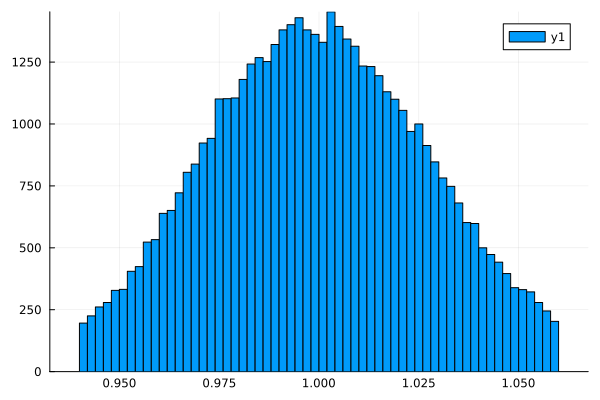

In [15]:
#Example
mu, sigma = prior_dict[var_x_names[1]]
var_dist = Truncated(LogNormal(mu,sigma), var_bounds_x[1], var_bounds_x[2])
vals = rand(var_dist,50000)
Plots.histogram(vals)

Aleatoric errors on BPM measurements include 0.15mm BPM error and an estimate of the surrogate model error in quadrature

In [16]:
nhbpm = 15
hy_error_priors = [ 0.15 for i in 1:nhbpm ]

nvbpm = 18
vy_error_priors = [ 0.15 for i in 1:nvbpm ]

#Add the model errors (std of validation errors)
model_err_h = 0.057
model_err_v = 0.017

for i in 1:nhbpm
    hy_error_priors[i] = sqrt( hy_error_priors[i]^2 + model_err_h^2 )
end
for i in 1:nhbpm
    vy_error_priors[i] = sqrt( vy_error_priors[i]^2 + model_err_v^2 )
end

In [17]:
@model function TuringModelDiffMultiBounded(
        hcontrol_base, hcontrol_pert, #nparam x nsample matrix of before/after currents (correctors + static magnet) for horizontal plane measurements 
        vcontrol_base, vcontrol_pert, #nparam x nsample matrix of before/after currents (correctors + static magnet) for vertical plane measurements 
        var_x_names,  var_y_names,   
        hobs, vobs, #nbpm x nsample matrix of horizontal/vertical plane measurements. Set to missing to sample from prior distribution
        prior_dict, #dictionary of priors as above
        var_bounds_x, var_bounds_y, #bounds on vars
        hobs_error_priors, vobs_error_priors, #aleatoric errors on bpms
        hsurrogate,hmu_std_x,hmu_std_y, nhbpm, #horizontal surrogate and norm info
        vsurrogate,vmu_std_x,vmu_std_y, nvbpm, #verticalhorizontal surrogate and norm info       
        ::Type{T} = Float64; 
        nhobs_in=nothing, nvobs_in=nothing, #if you pass missing for the hobs/vobs you must pass in the number of observations
        model_on_gpu=true) where {T}  

    nhobs = size(hcontrol_base,2)
    @assert size(hcontrol_pert,2) == nhobs
    if hobs === missing        
        hobs = Matrix{T}(undef, nhbpm, nhobs)
    else
        @assert size(hobs, 2) == nhobs
    end

    nvobs = size(vcontrol_base,2)
    @assert size(vcontrol_pert,2) == nvobs
    if vobs === missing        
        vobs = Matrix{T}(undef, nvbpm, nvobs)
    else
        @assert size(vobs, 2) == nvobs
    end    
    
    #Prior distributions for vars
    var_x_mu = [ prior_dict[i][1] for i in var_x_names ]
    var_x_sigma = [ prior_dict[i][2] for i in var_x_names ]    
    var_x ~ arraydist( [ Truncated(LogNormal(var_x_mu[i],var_x_sigma[i]), var_bounds_x[1], var_bounds_x[2] ) for i in 1:24 ] )

    var_y_mu = [ prior_dict[i][1] for i in var_y_names ]
    var_y_sigma = [ prior_dict[i][2] for i in var_y_names ]    
    var_y ~ arraydist( [ Truncated(LogNormal(var_y_mu[i],var_y_sigma[i]), var_bounds_y[1], var_bounds_y[2] ) for i in 1:24 ] )
    
    #get horizontal predictions as a batch call
    hvar_x_m = reduce(hcat,[ var_x for i in 1:nhobs])
    hvar_y_m = reduce(hcat,[ var_y for i in 1:nhobs])
    hxvals_base = vcat(hcontrol_base, hvar_x_m, hvar_y_m)   
    #hypred_base, hypred_base_J = predictManyWithJacobian(hsurrogate, hxvals_base, hmu_std_x, hmu_std_y, model_on_gpu=model_on_gpu)
    hypred_base = predictMany(hsurrogate, hxvals_base, hmu_std_x, hmu_std_y, model_on_gpu=model_on_gpu)

    ## We can't compute the Jacobian during the forward process as it interferes with Turing's autodiff. It's wasteful anyway as model
    ## return values are not stored at sampling time, but are regenerated by "generated_quantities" after the fact. 

    hxvals_pert = vcat(hcontrol_pert, hvar_x_m, hvar_y_m)   
    #hypred_pert, hypred_pert_J = predictManyWithJacobian(hsurrogate, hxvals_pert, hmu_std_x, hmu_std_y, model_on_gpu=model_on_gpu)
    hypred_pert = predictMany(hsurrogate, hxvals_pert, hmu_std_x, hmu_std_y, model_on_gpu=model_on_gpu)

    hypred_diff = hypred_pert .- hypred_base #orbit response

    #get vertical predictions
    vvar_x_m = reduce(hcat,[ var_x for i in 1:nvobs])
    vvar_y_m = reduce(hcat,[ var_y for i in 1:nvobs])

    vxvals_base = vcat(vcontrol_base, vvar_x_m, vvar_y_m)   
    #vypred_base, vypred_base_J = predictManyWithJacobian(vsurrogate, vxvals_base, vmu_std_x, vmu_std_y, model_on_gpu=model_on_gpu)
    vypred_base = predictMany(vsurrogate, vxvals_base, vmu_std_x, vmu_std_y, model_on_gpu=model_on_gpu)

    vxvals_pert = vcat(vcontrol_pert, vvar_x_m, vvar_y_m)   
    #vypred_pert, vypred_pert_J = predictManyWithJacobian(vsurrogate, vxvals_pert, vmu_std_x, vmu_std_y, model_on_gpu=model_on_gpu)
    vypred_pert = predictMany(vsurrogate, vxvals_pert, vmu_std_x, vmu_std_y, model_on_gpu=model_on_gpu)

    vypred_diff = vypred_pert .- vypred_base

    #Add aleatoric errors
    for i in 1:nhbpm
        for j in 1:nhobs
            hobs[i,j] ~ Normal( hypred_diff[i,j], sqrt(2.0)*hobs_error_priors[i] )
        end
    end    
    for i in 1:nvbpm
        for j in 1:nvobs
            vobs[i,j] ~ Normal( vypred_diff[i,j], sqrt(2.0)*vobs_error_priors[i] )
        end
    end  

    #Return some meta information for later use if desired
    return (hmodel_inputs=vcat(hcontrol_base,hcontrol_pert,hvar_x_m,hvar_y_m),        
        vmodel_inputs=vcat(vcontrol_base,vcontrol_pert,vvar_x_m,vvar_y_m),        
        hobs=hobs, vobs=vobs, predictions=(hypred_base, hypred_pert, vypred_base, vypred_pert),
        #jacobians=(hypred_base_J,hypred_pert_J,vypred_base_J,vypred_pert_J)
        )
        
end

TuringModelDiffMultiBounded (generic function with 4 methods)

# Define sample method for currents

## Sobol sampling method (not yet used)

To account for fluctuations in the currents we can use a Sobol uniform pseudorandom sampling scheme used for generating the surrogate training data

In [ ]:
using Sobol

In [ ]:
#These are the bounds (lo,hi) for sampling the static magnet currents, based on the distributions of the data
cur_bounds = Dict()
cur_bounds["idipo"] = (2286.0,2293.0)
cur_bounds["iqhc"] = (414.0,419.0)
cur_bounds["iqvc"] = (-232.0, -227.0)
cur_bounds["ish"] = (-0.15,0.01)
cur_bounds["isv"] = (-0.05,0.09)


In [ ]:
#Fluctuations of the corrector currents around the set points
hcorrector_fluct_bounds = (-4.5,2.5) #actual observed range -3.8087100982666016 1.722769856452942 around the set point
vcorrector_fluct_bounds = (-2.5,4.5) #actual observed range -1.8668172359466553 3.657613754272461 around the set point


In [ ]:
#Var sampling bounds
var_sample_bounds = (0.96,1.04)

In [ ]:
#For Sobol we convert to ranges: (lo, hi-lo)
hranges = Vector{Tuple{Float64,Float64}}(undef, length(hdimnames))
vranges = Vector{Tuple{Float64,Float64}}(undef, length(vdimnames))
hoff = 1
voff = 1

#Ensure we use the same order the model expects: correctors, static currents, xvars, yvars

#For correctors the range is only the fluctuation about the set point; we will shift the set point later
rg = (hcorrector_fluct_bounds[1],  hcorrector_fluct_bounds[2] - hcorrector_fluct_bounds[1])
for dn in cx_l
    hranges[hoff] = rg
    hoff+=1
end
rg = (vcorrector_fluct_bounds[1],  vcorrector_fluct_bounds[2] - vcorrector_fluct_bounds[1])
for dn in cy_l
    vranges[hoff] = rg
    voff+=1
end  

#For the static currents get the ranges from the bounds above
for dn in currents    
    start = cur_bounds[dn][1]
    range = cur_bounds[dn][2] - cur_bounds[dn][1]
    hranges[hoff] = (start,range)
    vranges[voff] = (start,range)
    hoff += 1
    voff += 1
end

#vars sample range
rg = (var_sample_bounds[1], var_sample_bounds[2] - var_sample_bounds[1])
for i in 1:48
    hranges[hoff] = rg
    vranges[voff] = rg
    hoff+=1
    voff+=1
end

In [ ]:
@assert length(hdimnames) == hoff - 1
@assert length(vdimnames) == voff - 1

In [ ]:
function SobolSample(Nsample, #number of samples
                     corrector_setpoint, #24-component array indicating the control-room setting of the correctors
                     ranges; #the ranges we computed above
                     sample_skip = 0, #Sobol is a sequence, so if you want to generate more independent data you must track where you are
                     sample_vars = false #whether to also sample the vars
    )    
    #Build the sampling plan; we will use the sample plan for each corrector setpoint and loop over correctors shifting the setpoint to +-220
    cors_plane=24 #number of correctors
    nstatic=5 #number od static magnet currents    
    dims = nstatic + cors_plane
    if sample_vars        
        dims += 48
    end
    
    SB = SobolSeq(dims)
    skip(SB, sample_skip, exact=true)       
    plan = [ next!(SB) for xx in 1:Nsample ]

    for s in 1:Nsample
        for d in 1:dims
            plan[s][d] = ranges[d][1] + plan[s][d]*ranges[d][2]
        end
    end

    cor_shift = zeros(Float64, dims)            
    cor_shift[1:cors_plane] = corrector_setpoint[:]
    
    #Samples for unperturbed
    out = Matrix{Float64}(undef, dims, Nsample )    
    for s in 1:Nsample
        out[:, s] = plan[s][:] + cor_shift
    end        
    return out
end


In [ ]:
#Example
setpoint = zeros(Float64, 24)
setpoint[1] = 22
xsamptest = SobolSample(100, setpoint, hranges)

In [ ]:
for i in 1:size(xsamptest,2)    
    p = Plots.scatter(xsamptest[i,:])
    display(p)
end

In [ ]:
#Generate an "experiment" (a set of magnet current values including fluctuations) for all the corrector set points
#in the 0-> +-22A data set
function generateExperiment0pm22Sobol(hranges, vranges; sample_skip = 0)    
    #Unperturbed data
    xunpert = SobolSample(48, zeros(Float64,24), hranges; sample_skip=sample_skip)
    sample_skip += 48
    yunpert = SobolSample(48, zeros(Float64,24), vranges; sample_skip=sample_skip)
    sample_skip += 48

    xpert = Matrix{Float64}(undef, size(xunpert,1), 48)
    ypert = Matrix{Float64}(undef, size(yunpert,1), 48)
    for cor in 1:24
        #+22A
        setpoint = zeros(Float64,24)
        setpoint[cor] = 22
        xpert[:, cor] = SobolSample(1, setpoint, hranges; sample_skip=sample_skip)
        sample_skip += 1
        ypert[:, cor] = SobolSample(1, setpoint, vranges; sample_skip=sample_skip)
        sample_skip += 1
        
        #-22A
        setpoint[cor] = -22
        xpert[:, cor+24] = SobolSample(1, setpoint, hranges; sample_skip=sample_skip)
        sample_skip += 1
        ypert[:, cor+24] = SobolSample(1, setpoint, vranges; sample_skip=sample_skip)
        sample_skip += 1
    end
    
    return xunpert, xpert, yunpert, ypert, sample_skip
end

#sample_skip = 0
#xunpert, xpert, yunpert, ypert, sample_skip = generateExperiment0pm22Sobol(hranges,vranges; sample_skip=sample_skip)


## Use fixed current values, ignoring power supply fluctuations

For our initial experiments we simplify the problem by fixing the static magnet currents and using the control settings for the correctors
i.e. ignoring the power supply fluctuations

In [18]:
function getCurrentsCentralValues(Nsample, #here just defines the number of identical columns
        corrector_setpoint #24-component array indicating the control-room setting of the correctors                    
    )    
    #central values of the readback currents from the data; we do not know the control room settings so we will use these instead
    static_magnet_cen = [2289.4692150987576, 417.22886520776996, -230.5854715200571, -0.0726923597234804, 0.04418094545619282]
        
    cors_plane=24 #number of correctors
    nstatic=5 #number od static magnet currents    
    dims = nstatic + cors_plane

    out = Matrix{Float64}(undef, dims, Nsample)
    for s in 1:Nsample
        out[1:cors_plane,s] = corrector_setpoint[:]
        out[cors_plane+1:end,s] = static_magnet_cen[:]        
    end
    return out    
end

getCurrentsCentralValues (generic function with 1 method)

# Sample prior predictive distribution

For our initial experiments we will discount the power supply fluctuations

In [19]:
#Generate experimental setups for the 0-> +-22A data set
function generateExperiment0pm22CentralValues()
    #Unperturbed data
    xunpert = getCurrentsCentralValues(48, zeros(Float64,24))    
    yunpert = getCurrentsCentralValues(48, zeros(Float64,24))    

    xpert = Matrix{Float64}(undef, size(xunpert,1), 48)
    ypert = Matrix{Float64}(undef, size(yunpert,1), 48)
    for cor in 1:24
        #+22A
        setpoint = zeros(Float64,24)
        setpoint[cor] = 22
        xpert[:, cor] = getCurrentsCentralValues(1, setpoint)        
        ypert[:, cor] = getCurrentsCentralValues(1, setpoint)        
        
        #-22A
        setpoint[cor] = -22
        xpert[:, cor+24] = getCurrentsCentralValues(1, setpoint)
        ypert[:, cor+24] = getCurrentsCentralValues(1, setpoint)
        
    end
    
    return xunpert, xpert, yunpert, ypert
end

xunpert, xpert, yunpert, ypert = generateExperiment0pm22CentralValues()

([0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; -0.0726923597234804 -0.0726923597234804 … -0.0726923597234804 -0.0726923597234804; 0.04418094545619282 0.04418094545619282 … 0.04418094545619282 0.04418094545619282], [22.0 0.0 … 0.0 0.0; 0.0 22.0 … 0.0 0.0; … ; -0.0726923597234804 -0.0726923597234804 … -0.0726923597234804 -0.0726923597234804; 0.04418094545619282 0.04418094545619282 … 0.04418094545619282 0.04418094545619282], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; -0.0726923597234804 -0.0726923597234804 … -0.0726923597234804 -0.0726923597234804; 0.04418094545619282 0.04418094545619282 … 0.04418094545619282 0.04418094545619282], [22.0 0.0 … 0.0 0.0; 0.0 22.0 … 0.0 0.0; … ; -0.0726923597234804 -0.0726923597234804 … -0.0726923597234804 -0.0726923597234804; 0.04418094545619282 0.04418094545619282 … 0.04418094545619282 0.04418094545619282])

In [21]:
Random.seed!(108944)

prior_sampler = TuringModelDiffMultiBounded(
        xunpert, xpert,
        yunpert, ypert, 
        var_x_names, var_y_names,
        missing, missing,
        prior_dict, var_bounds_x, var_bounds_y,
        hy_error_priors, vy_error_priors, 
        hmodel_gpu, hsurrogate[2], hsurrogate[3], nhbpm,
        vmodel_gpu, vsurrogate[2], vsurrogate[3], nvbpm,        
    )

prior_chains = []
for i in 1:5
    prior_chain = Turing.sample(prior_sampler, Prior(), 50000) 
    jldsave(string("prior_chain_",i, ".jld2"); prior_chain)
    push!(prior_chains, prior_chain)
end

Sampling: 100%|█████████████████████████████████████████| Time: 0:02:59
Sampling: 100%|█████████████████████████████████████████| Time: 0:02:58
Sampling: 100%|█████████████████████████████████████████| Time: 0:03:02
Sampling: 100%|█████████████████████████████████████████| Time: 0:03:17
Sampling: 100%|█████████████████████████████████████████| Time: 0:03:11


In [22]:
function getParamFromChain(param, chain)
    p = Symbol(param)
    aa = Turing.get(chain, p)    
    a = aa[p] #Turing.get(chain, p)[p]
    return vcat(a...) #flatten if multiple chains    
end
function getObsFromChain(hobsorvobs, nbpm, nobs, chain)
    chain_len = length(getParamFromChain(string(hobsorvobs,"[1, 1]"), chain))    
    out = Array{Float64,3}(undef, nbpm, nobs, chain_len)
    for bpm in 1:nbpm
        for obs in 1:nobs
            out[bpm,obs,:] = getParamFromChain(string(hobsorvobs,"[",bpm,", ",obs,"]"), chain) 
        end
    end
    return out
end

getObsFromChain (generic function with 1 method)

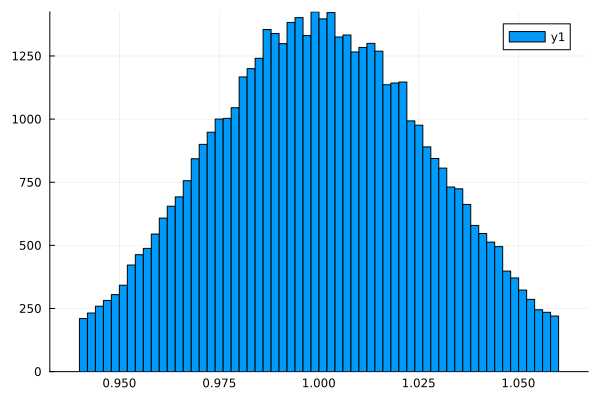

In [23]:
#Vars distributions should be centered on the null result
Plots.histogram(getParamFromChain("var_x[1]", prior_chains[1]))

In [24]:
#Obtain the prior predictive distribution for the horizontal orbit
#Tensor nhbpm x nobs x nMCMCsamples
#where nobs is the number of x-orbit observations in our data set (i.e 48 here: +-22A for each corrector)
hobs_prior_pred = getObsFromChain("hobs", nhbpm, 48, prior_chains[1])

15×48×50000 Array{Float64, 3}:
[:, :, 1] =
  9.34752    1.2836    -8.20289   …   7.8298     8.01837  -3.98519
  5.39175    2.88012   -2.74463       3.05343    5.27785   0.357693
 -7.83017   -2.30925    5.73454      -6.37224   -7.32493   1.68206
 -0.109444  -2.6526    -2.05812       1.45631   -1.16535  -2.66812
  3.17041    3.26466   -0.988101      0.786273   4.06163   1.56312
 -6.40488   -2.56918    4.13331   …  -4.0167    -6.25249   0.646168
  7.95905    1.00953   -7.12702       6.97735    6.20458  -3.40185
 -4.944     -2.3602     2.95581      -3.85723   -4.91442   0.606093
  5.19424   -2.21144   -6.841         6.2816     2.62028  -5.27134
  8.11911    0.969305  -7.03683       7.39079    6.90211  -3.10514
 -0.113294   2.44716    2.94569   …  -1.91036    1.25171   3.38568
 -9.19928    0.437244   8.94728      -9.02231   -6.22604   5.68515
 -3.58731   -2.14396    1.92601      -2.24538   -3.7045   -0.796633
  7.47075   -1.82495   -8.2004        7.74241    4.48903  -5.3396
 -2.36947    2.3

In [25]:
#Note 18 BPMs in the y-direction
vobs_prior_pred = getObsFromChain("vobs", nvbpm, 48, prior_chains[1])

18×48×50000 Array{Float64, 3}:
[:, :, 1] =
 -0.657395    1.84575    2.00113   …   0.297366   -1.48253    -1.30178
  1.60696    -0.290382   1.27357       2.17284     0.326461   -1.66403
  1.98634     0.677723  -1.01686       1.20233     1.93885    -0.468229
 -0.748976    0.725244   1.59342      -1.36417     1.00615     1.34958
 -2.50664    -0.498785   2.16878      -1.62439    -1.42212     0.548732
  1.40526    -0.405251  -2.44908   …   2.09932     0.652927   -1.78718
  1.64007     0.989067  -0.952394      1.44959     1.77703     0.0479917
 -0.275503    1.33053    1.29506      -1.00045     0.494609    1.84644
 -1.6807      0.134386   1.89556      -2.3481     -1.38639     1.0401
 -0.977733   -1.38715   -0.053013     -0.0585707  -1.73363    -0.74084
  0.536482    1.37034    0.754984  …  -0.635078    1.99054     1.49508
 -1.55449     0.565599   2.14227      -1.63787    -0.0938433   1.5512
  0.822259    1.26521    0.32749      -0.177032    1.64416     1.278
 -1.49339     1.17281    1.76407  

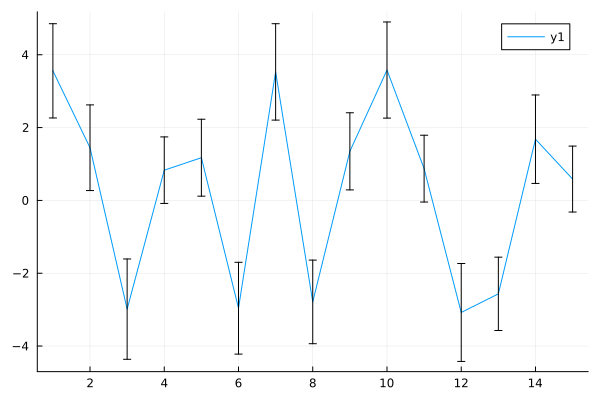

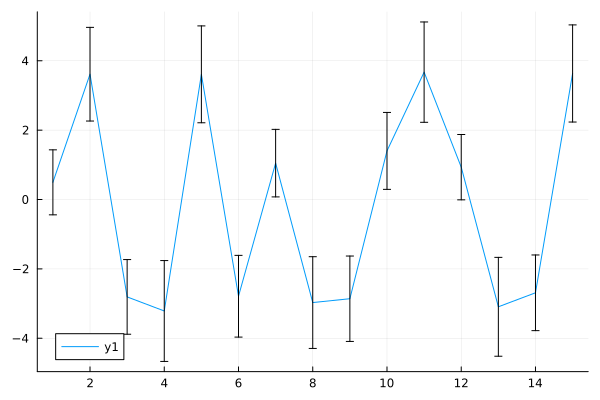

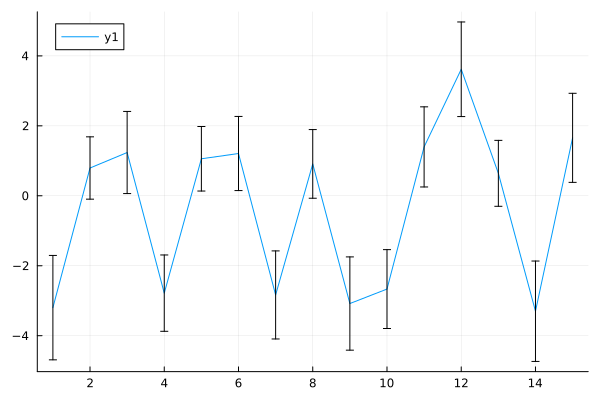

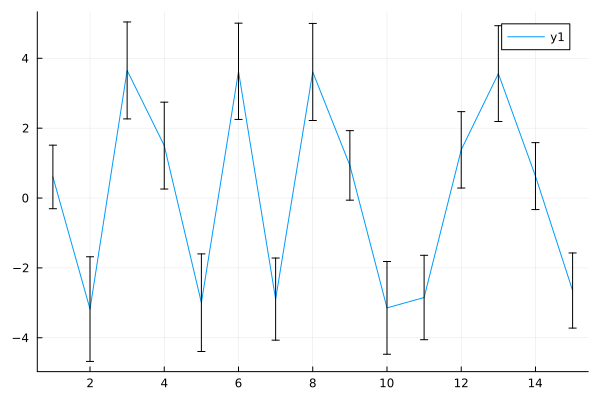

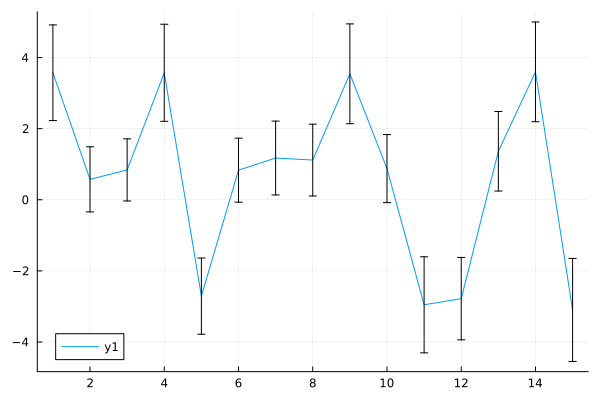

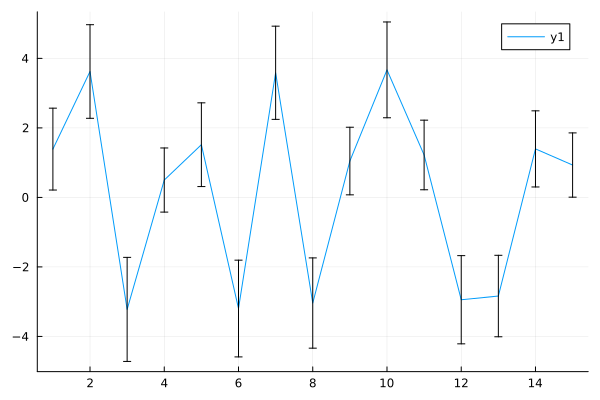

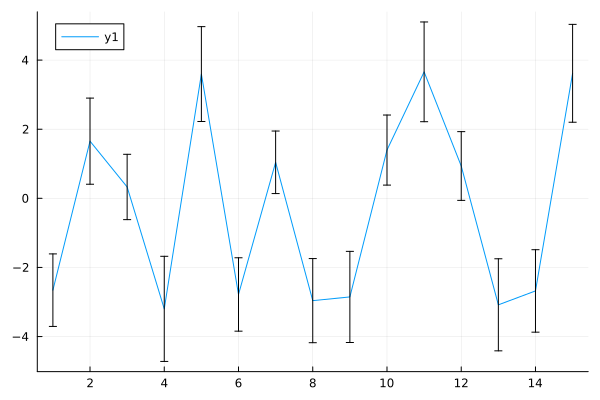

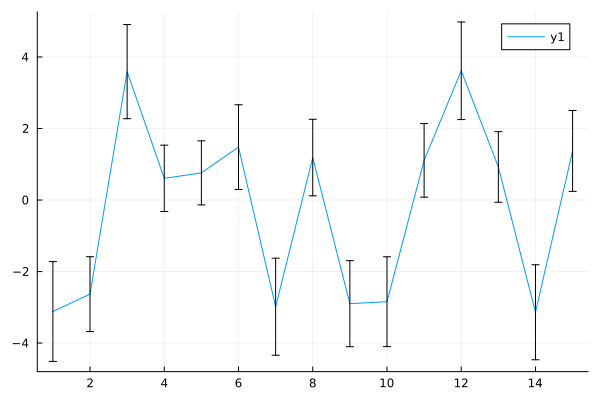

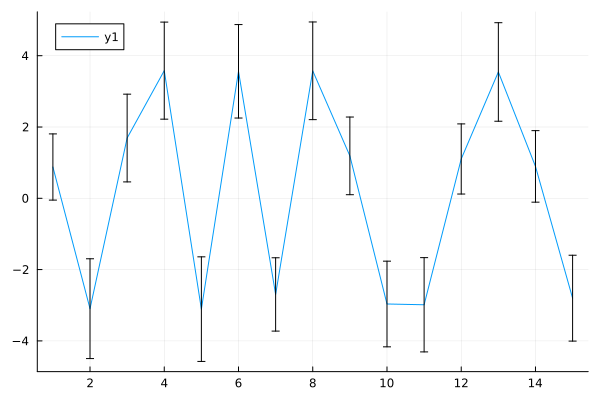

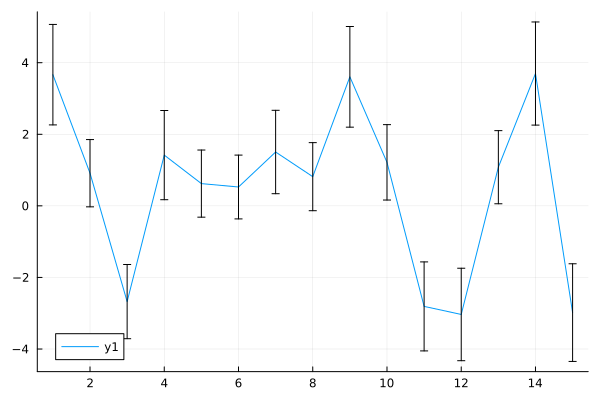

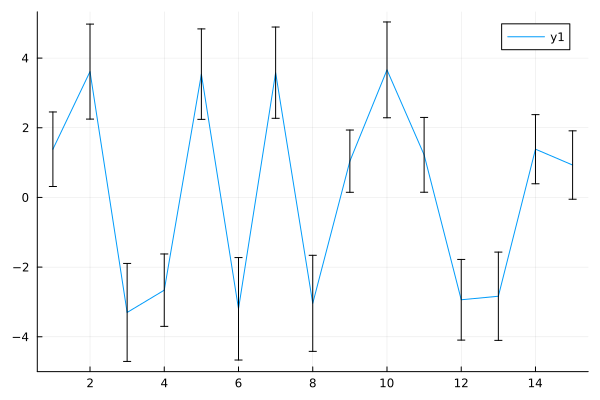

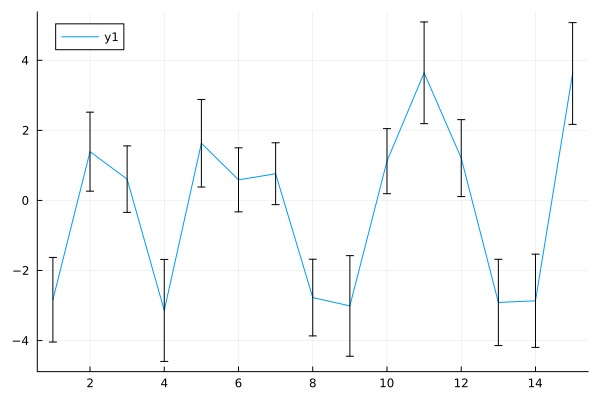

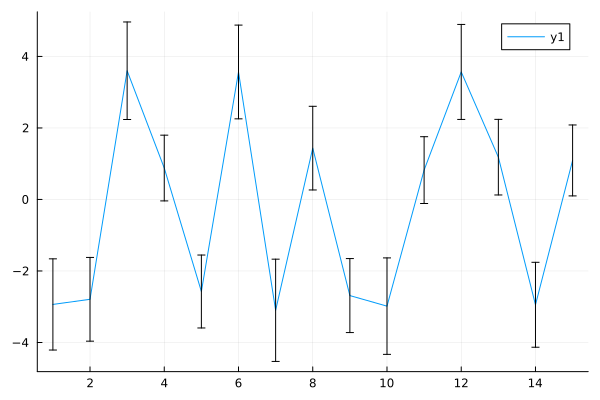

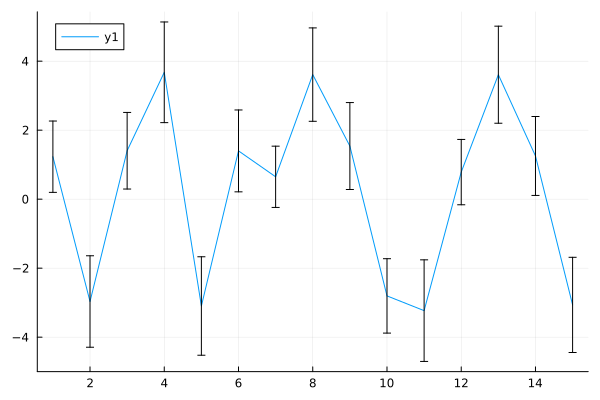

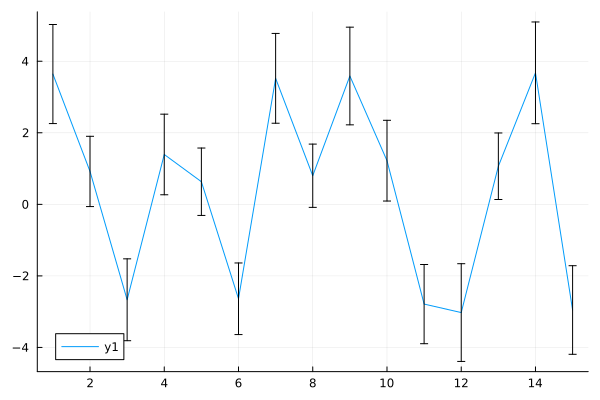

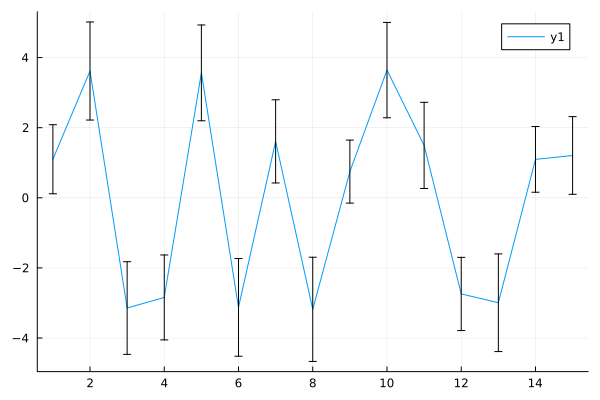

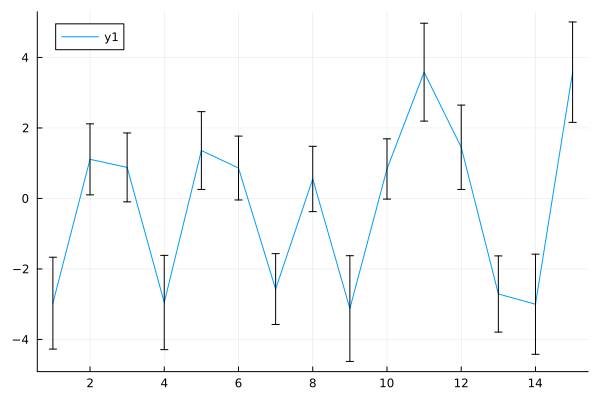

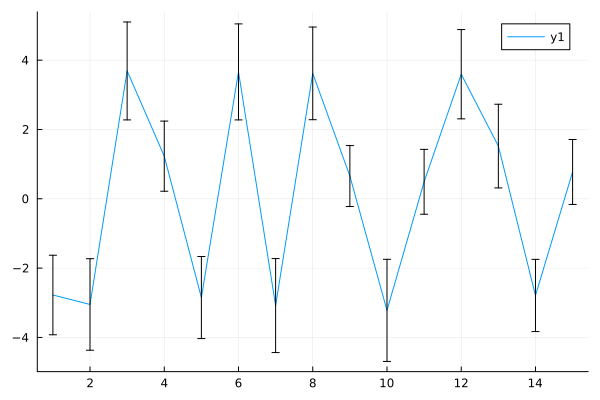

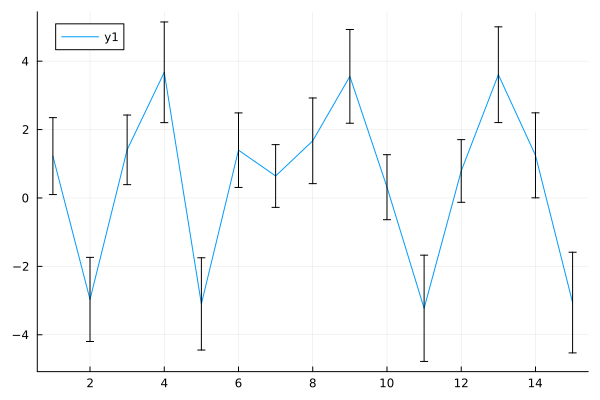

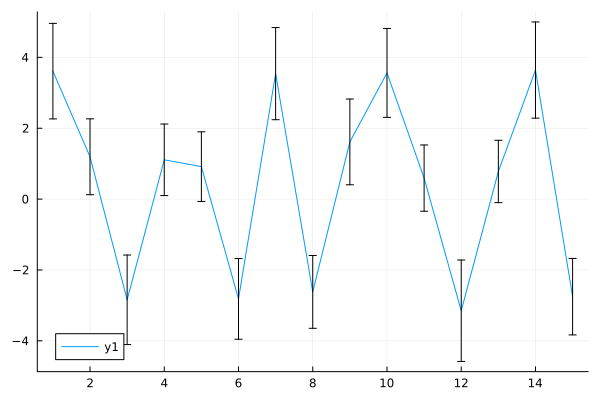

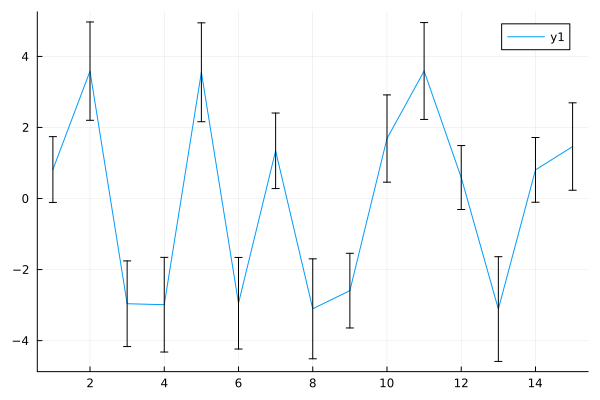

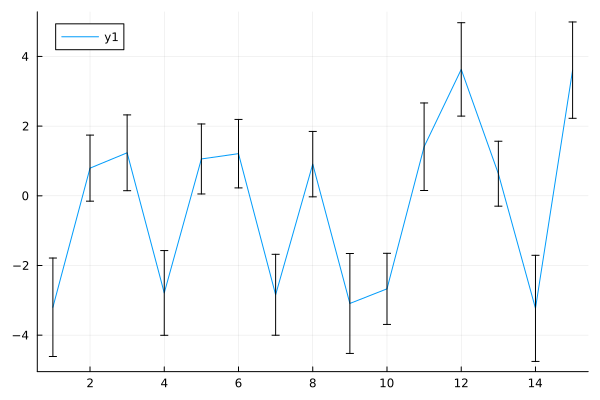

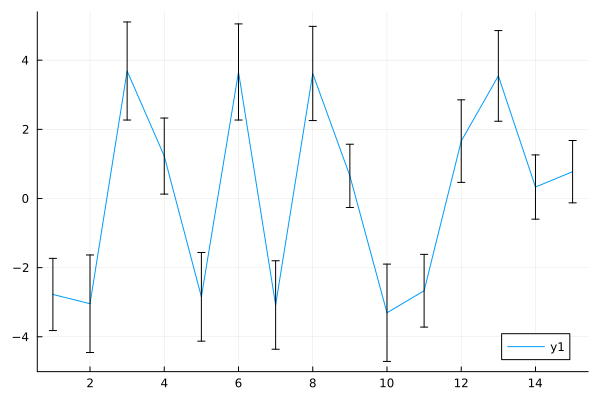

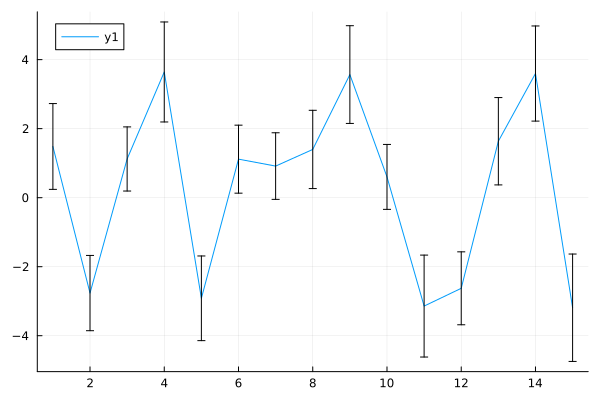

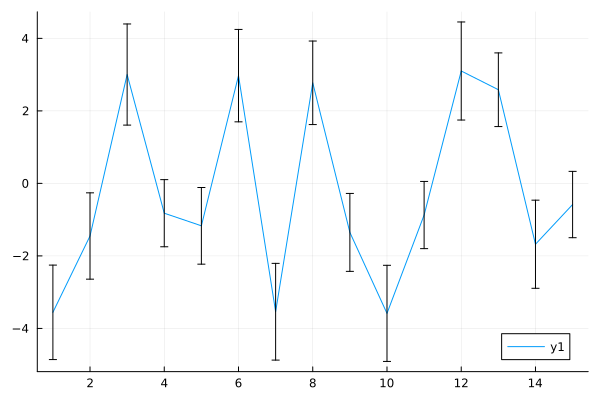

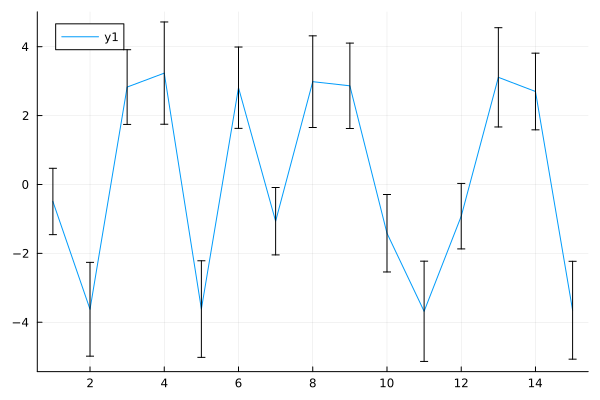

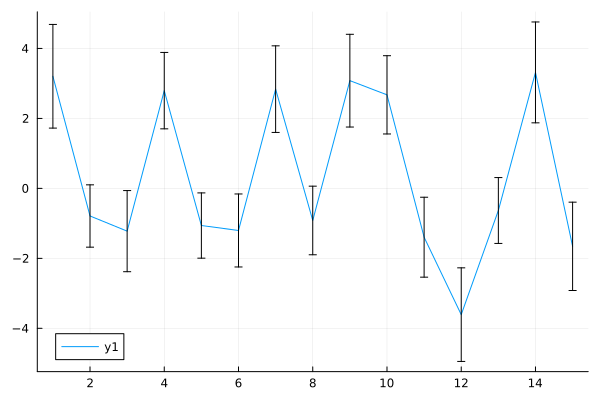

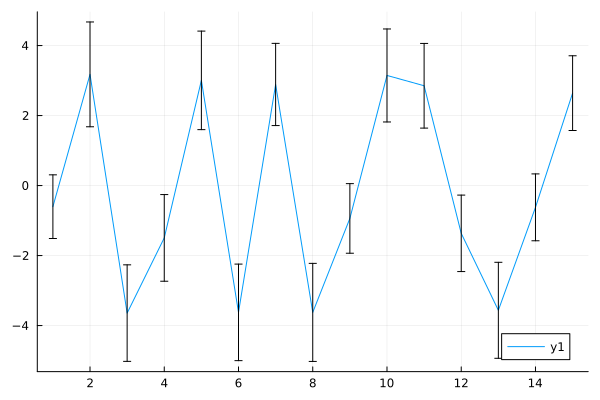

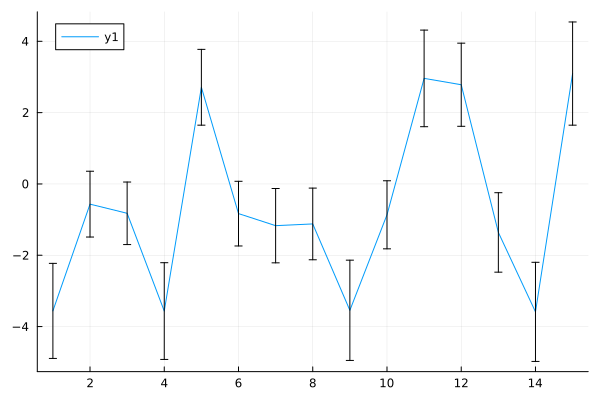

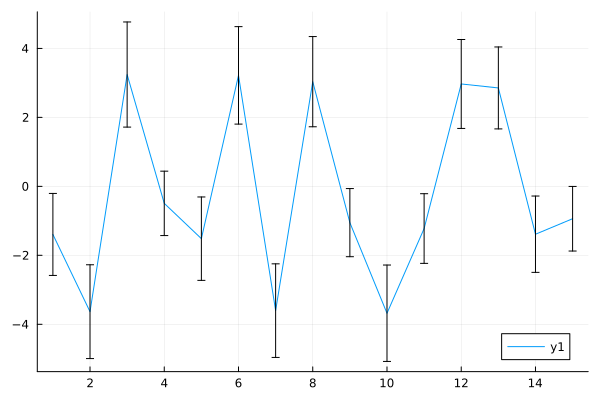

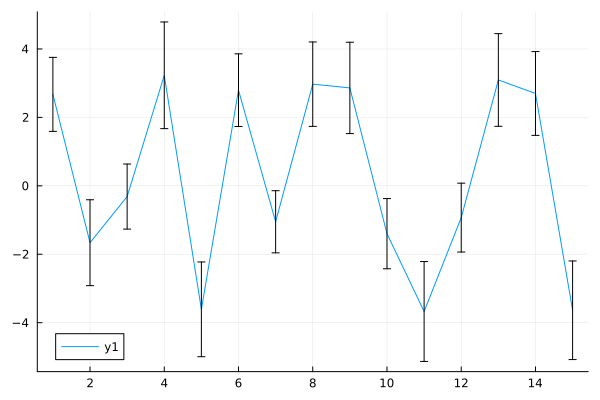

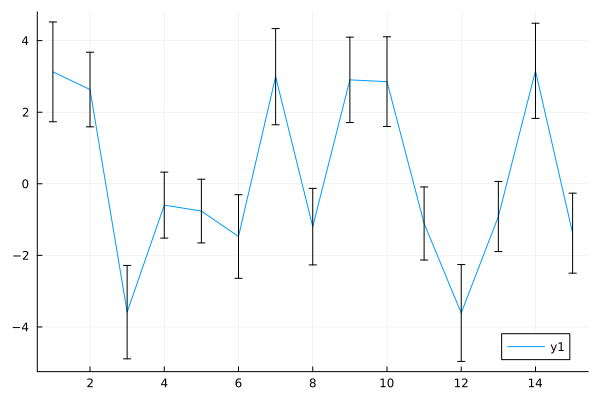

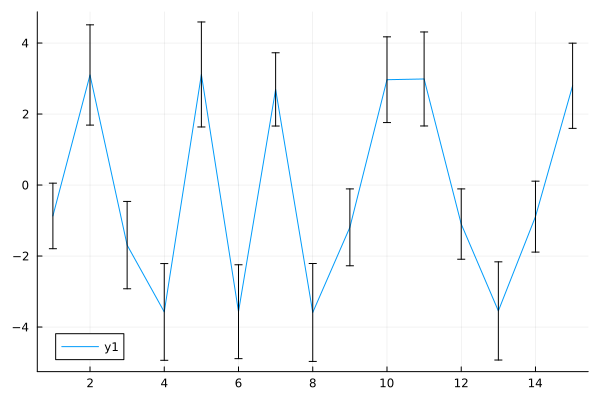

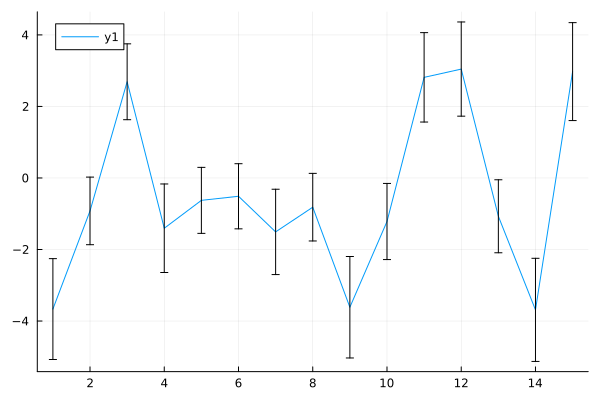

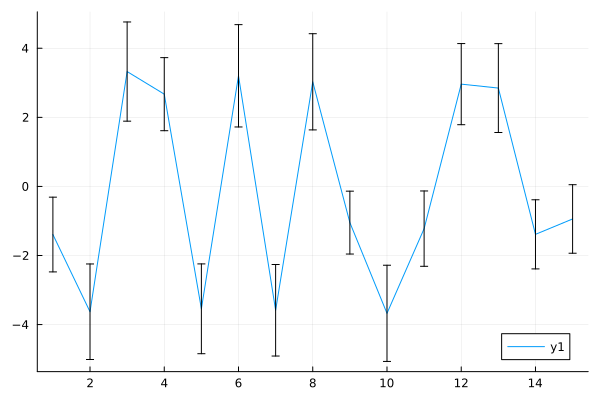

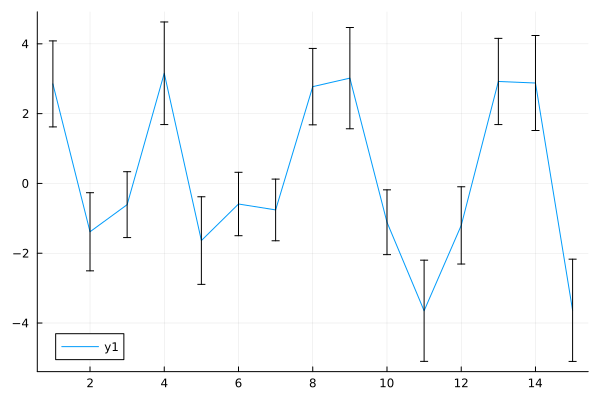

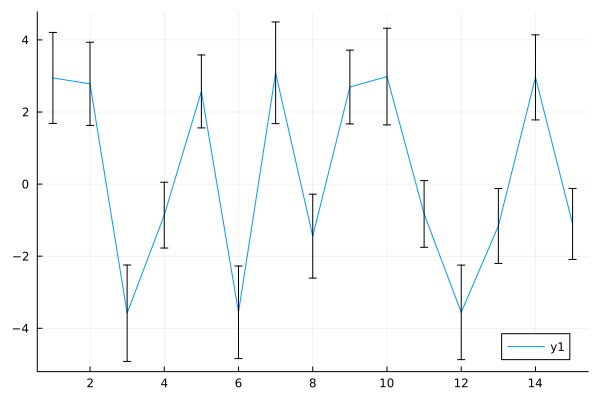

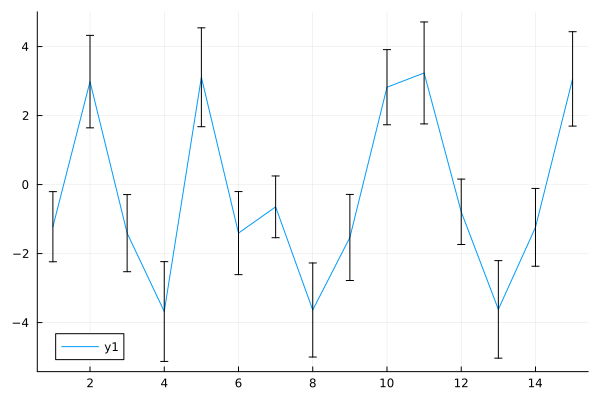

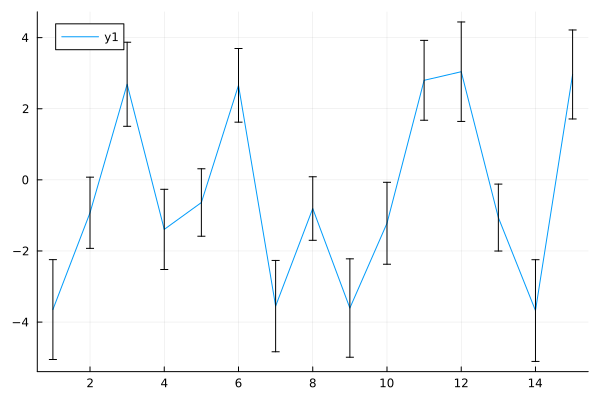

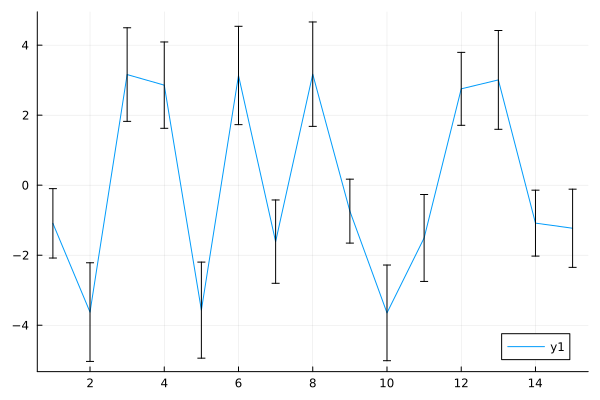

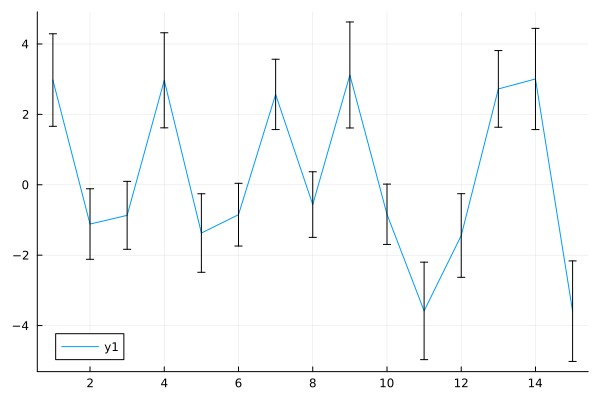

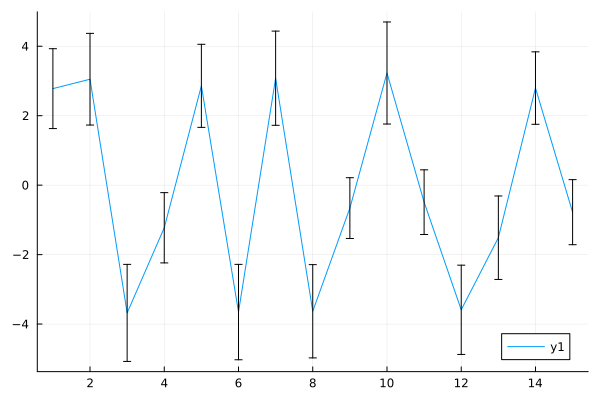

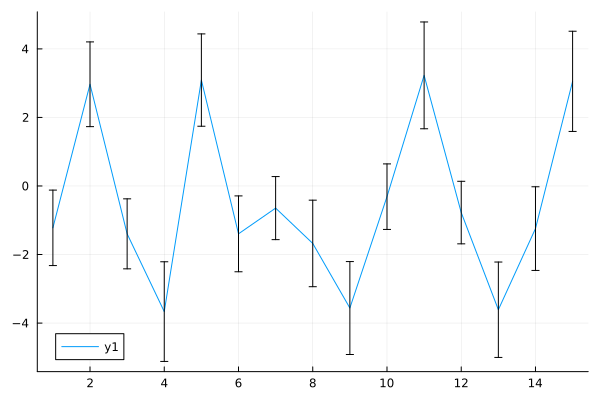

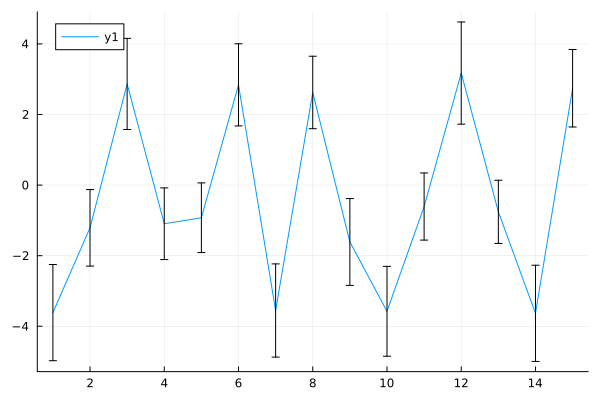

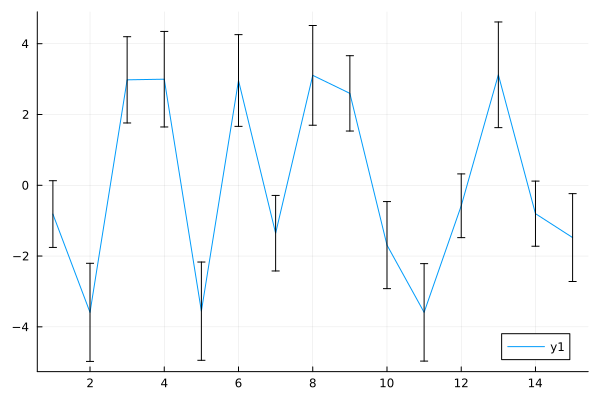

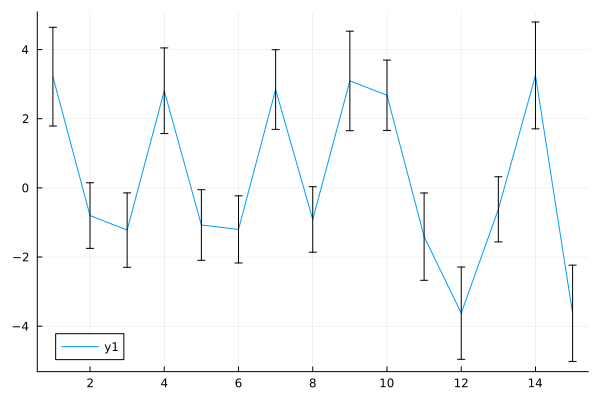

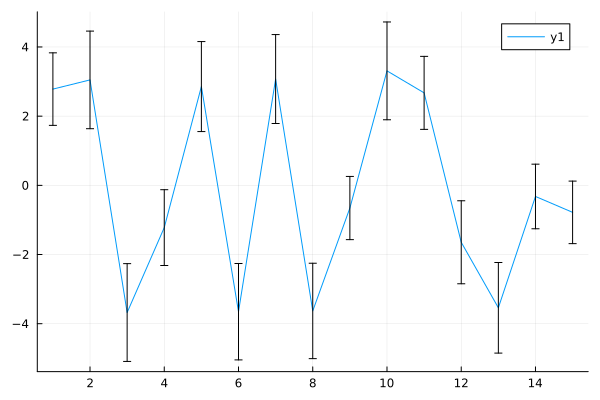

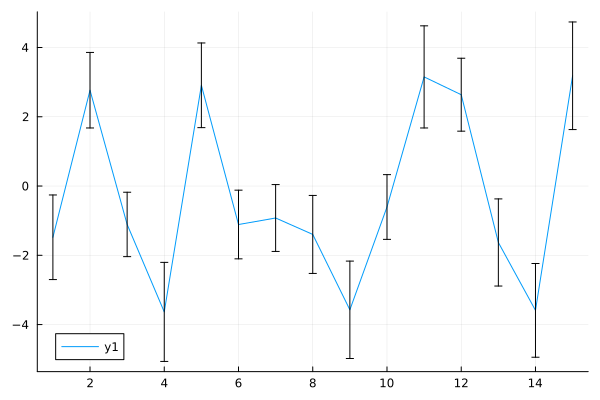

In [26]:
for expt in 1:48
    p= Plots.plot(mean(hobs_prior_pred[:,expt,:], dims=2),  yerror=std(hobs_prior_pred[:,expt,:], dims=2) )
    display(p)
end

In [28]:
prior_chains[1]

Chains MCMC chain (50000×1635×1 Array{Float64, 3}):

Iterations        = 1:1:50000
Number of chains  = 1
Samples per chain = 50000
Wall duration     = 183.82 seconds
Compute duration  = 183.82 seconds
parameters        = var_x[1], var_x[2], var_x[3], var_x[4], var_x[5], var_x[6], var_x[7], var_x[8], var_x[9], var_x[10], var_x[11], var_x[12], var_x[13], var_x[14], var_x[15], var_x[16], var_x[17], var_x[18], var_x[19], var_x[20], var_x[21], var_x[22], var_x[23], var_x[24], var_y[1], var_y[2], var_y[3], var_y[4], var_y[5], var_y[6], var_y[7], var_y[8], var_y[9], var_y[10], var_y[11], var_y[12], var_y[13], var_y[14], var_y[15], var_y[16], var_y[17], var_y[18], var_y[19], var_y[20], var_y[21], var_y[22], var_y[23], var_y[24], hobs[1, 1], hobs[2, 1], hobs[3, 1], hobs[4, 1], hobs[5, 1], hobs[6, 1], hobs[7, 1], hobs[8, 1], hobs[9, 1], hobs[10, 1], hobs[11, 1], hobs[12, 1], hobs[13, 1], hobs[14, 1], hobs[15, 1], hobs[1, 2], hobs[2, 2], hobs[3, 2], hobs[4, 2], hobs[5, 2], hobs[6, 2], hobs[7, 2],

# Generate fake data with no current fluctuations for initial expt

For testing our method we need one or more "experiments" with no current fluctuations to run inference upon, 
for which we use the surrogate to generate fake data.

For simplicity, we will set all the vars in the fake data to the null value, so the only fluctuations come from the aleatoric
errors

In [ ]:
#Use Turing to generate the fake data for simplicity
@model function TuringModelAleatoricNull(
        hcontrol_base, hcontrol_pert, #nparam x nsample matrix of before/after currents (correctors + static magnet) for horizontal plane measurements 
        vcontrol_base, vcontrol_pert, #nparam x nsample matrix of before/after currents (correctors + static magnet) for vertical plane measurements 
        var_x_names,  var_y_names,   
        hobs, vobs, #nbpm x nsample matrix of horizontal/vertical plane measurements. Set to missing to sample from prior distribution
        prior_dict, #dictionary of priors as above        
        hobs_error_priors, vobs_error_priors, #aleatoric errors on bpms
        hsurrogate,hmu_std_x,hmu_std_y, nhbpm, #horizontal surrogate and norm info
        vsurrogate,vmu_std_x,vmu_std_y, nvbpm, #verticalhorizontal surrogate and norm info       
        ::Type{T} = Float64; 
        nhobs_in=nothing, nvobs_in=nothing, #if you pass missing for the hobs/vobs you must pass in the number of observations
        model_on_gpu=true) where {T}  

    nhobs = size(hcontrol_base,2)
    @assert size(hcontrol_pert,2) == nhobs
    if hobs === missing        
        hobs = Matrix{T}(undef, nhbpm, nhobs)
    else
        @assert size(hobs, 2) == nhobs
    end

    nvobs = size(vcontrol_base,2)
    @assert size(vcontrol_pert,2) == nvobs
    if vobs === missing        
        vobs = Matrix{T}(undef, nvbpm, nvobs)
    else
        @assert size(vobs, 2) == nvobs
    end    
        
    var_x = [1.0 for i in 1:24]
    var_y = [1.0 for i in 1:24]
    
    #get horizontal predictions as a batch call
    hvar_x_m = reduce(hcat,[ var_x for i in 1:nhobs])
    hvar_y_m = reduce(hcat,[ var_y for i in 1:nhobs])
    hxvals_base = vcat(hcontrol_base, hvar_x_m, hvar_y_m)   
    hypred_base = predictMany(hsurrogate, hxvals_base, hmu_std_x, hmu_std_y, model_on_gpu=model_on_gpu)

    hxvals_pert = vcat(hcontrol_pert, hvar_x_m, hvar_y_m)   
    hypred_pert = predictMany(hsurrogate, hxvals_pert, hmu_std_x, hmu_std_y, model_on_gpu=model_on_gpu)

    hypred_diff = hypred_pert .- hypred_base #orbit response

    #get vertical predictions
    vvar_x_m = reduce(hcat,[ var_x for i in 1:nvobs])
    vvar_y_m = reduce(hcat,[ var_y for i in 1:nvobs])

    vxvals_base = vcat(vcontrol_base, vvar_x_m, vvar_y_m)   
    vypred_base = predictMany(vsurrogate, vxvals_base, vmu_std_x, vmu_std_y, model_on_gpu=model_on_gpu)

    vxvals_pert = vcat(vcontrol_pert, vvar_x_m, vvar_y_m)   
    vypred_pert = predictMany(vsurrogate, vxvals_pert, vmu_std_x, vmu_std_y, model_on_gpu=model_on_gpu)

    vypred_diff = vypred_pert .- vypred_base

    #Add aleatoric errors
    for i in 1:nhbpm
        for j in 1:nhobs
            hobs[i,j] ~ Normal( hypred_diff[i,j], sqrt(2.0)*hobs_error_priors[i] )
        end
    end    
    for i in 1:nvbpm
        for j in 1:nvobs
            vobs[i,j] ~ Normal( vypred_diff[i,j], sqrt(2.0)*vobs_error_priors[i] )
        end
    end  

    #Return some meta information for later use if desired
    return vcat(hcontrol_base,hcontrol_pert,hvar_x_m,hvar_y_m), vcat(vcontrol_base,vcontrol_pert,vvar_x_m,vvar_y_m),  hobs, vobs
end

In [ ]:
Random.seed!(108944)

fakedata_sampler = TuringModelAleatoricNull(
        xunpert, xpert,
        yunpert, ypert, 
        var_x_names, var_y_names,
        missing, missing,
        prior_dict,
        hy_error_priors, vy_error_priors, 
        hmodel_gpu, hsurrogate[2], hsurrogate[3], nhbpm,
        vmodel_gpu, vsurrogate[2], vsurrogate[3], nvbpm,        
    )
fakedata_chain = Turing.sample(fakedata_sampler, Prior(), 2000)    

# Inference on fake data

I define an "observation" as one orbit response measurement for a particular corrector being changed from some initial to final current setting, and one "experiment" as the set of 48 observations obtained by looping over each corrector and measuring its response at both settings. I define a "data set" as the the subset of all available measured observations for a particular choice of initial and final current setting. Given that we have multiple repetitions of each observation, there are many experiments I can draw for a particular data set.
 
In the paper I performed inference separately for between 4 and 8 experiments per data set (with the observations drawn randomly from among the repetitions).

Here we will focus on the 0->+-22A data set, and will perform the inference for multiple experiments.

In [ ]:
# Each sample in the chain of the fake data is a different experiment
hobs_experiments = getObsFromChain("hobs", nhbpm, 48, fakedata_chain)
vobs_experiments = getObsFromChain("vobs", nvbpm, 48, fakedata_chain)

In [ ]:
using Serialization
Serialization.serialize("inference_inputs.ser", (xunpert=xunpert, xpert=xpert, yunpert=yunpert, ypert=ypert,
     hobs_experiments=hobs_experiments, vobs_experiments=vobs_experiments) ) 

In [ ]:
if 0
    expt_idx = 1
    
    Random.seed!(168764 + expt_idx)
    
    sampler = TuringModelDiffMultiBounded(
            xunpert, xpert,
            yunpert, ypert, 
            var_x_names, var_y_names,
            hobs_experiments[:,:,expt_idx], vobs_experiments[:,:,expt_idx],
            prior_dict, var_bounds_x, var_bounds_y,
            hy_error_priors, vy_error_priors, 
            hmodel_gpu, hsurrogate[2], hsurrogate[3], nhbpm,
            vmodel_gpu, vsurrogate[2], vsurrogate[3], nvbpm,        
        )
    map_estimate = maximum_a_posteriori(sampler)
    display(map_estimate)
    
    chain = Turing.sample(sampler, NUTS(0.65; adtype=AutoForwardDiff()), 2000; initial_params=InitFromParams(map_estimate.params))
    accepted = Vector(get(chain; section=[:internals])[:is_accept][:,1])
    acceptance = sum(accepted)/length(accepted)
    println("Acceptance : ", acceptance)
end

In [ ]:
using OrderedCollections
using JLD2

function patchBrokenChain(chn)
    #Thanks ChatGPT
    oldmap = chn.info.varname_to_symbol
    newmap = OrderedDict{keytype(oldmap), valtype(oldmap)}()

    for (vn, sym) in oldmap
        newmap[vn] = sym
    end
    @assert all(haskey(newmap, vn) for vn in keys(newmap))

    newinfo = merge(chn.info, (varname_to_symbol = newmap,))
    return Chains(chn.value.data, names(chn), chn.name_map; info = newinfo)    
end    

#Reload the chains I previously generated
posterior_chains = []
for i in 1:12
    #chn = Serialization.deserialize(string("posterior_chain_",i,"_mcmcchains.ser"))
    #Prefer the JLD2 versions for long-term storability
    chn= jldopen(string("posterior_chain_",i,".jld2"), "r+")["chn2"]

    #Note that both Serialization and JLD2 do not prevent incompatibilities in the hashing used for serialized dictionaries
    #thus we can find that the symbol dictionary is internally inconsistent and it must be patched
    oldmap = chn.info.varname_to_symbol
    vn = first(keys(oldmap))
    if haskey(oldmap, vn) == false # incorrectly false
        println("Applying patch to dictionary hashtable for chain ",i)
        chn = patchBrokenChain(chn)
    end
    push!(posterior_chains, chn)
end

generated_quantities gives us the "return values" from the Turing model, including model inputs and outputs

## Generate and store "generated_quantities"

In [ ]:
inference_model_outputs = []

for i in 1:12    
    sampler = TuringModelDiffMultiBounded(
            xunpert, xpert,
            yunpert, ypert, 
            var_x_names, var_y_names,
            hobs_experiments[:,:,i], vobs_experiments[:,:,i],
            prior_dict, var_bounds_x, var_bounds_y,
            hy_error_priors, vy_error_priors, 
            hmodel_gpu, hsurrogate[2], hsurrogate[3], nhbpm,
            vmodel_gpu, vsurrogate[2], vsurrogate[3], nvbpm,        
        )
    gq= generated_quantities(sampler, posterior_chains[i])
    push!(inference_model_outputs, gq)
end

In [ ]:
for i in 1:12
    outputs = inference_model_outputs[i]
    jldsave(string("inference_model_outputs", i, ".jld2"); outputs)
end

### Compute Jacobians (these cannot be done at inference time as they interefered with Turing's autodiff)

In [ ]:
size(inference_model_outputs[1])

In [ ]:
#input and output mu, std for horizontal plane model (for normalization)
hmu_std_x = hsurrogate[2]
hmu_std_y = hsurrogate[3]
vmu_std_x = vsurrogate[2]
vmu_std_y = vsurrogate[3]

for expt_idx in 1:12
    println(expt_idx)
    nsample = size(inference_model_outputs[expt_idx],1)
    jacobians = []
    for sample in 1:nsample
        if sample % 1 == 0
            println(sample,"/",nsample)
        end
        
        #Model inputs for *batched* model; these accept matrices where the number of columns is the number of observations
        hmodel_inputs = inference_model_outputs[expt_idx][sample][:hmodel_inputs]
        hcontrol_base = hmodel_inputs[1:29,:]
        hcontrol_pert = hmodel_inputs[30:58,:]
        
        vmodel_inputs = inference_model_outputs[expt_idx][sample][:vmodel_inputs]
        vcontrol_base = vmodel_inputs[1:29,:]
        vcontrol_pert = vmodel_inputs[30:58,:]
        
        #Note that the var matrices have identical columns for a given sample;
        #the distinction between hvar_x, and vvar_x is simply the number of columns, which is the number of observations in that plane
        hvar_x = hmodel_inputs[59:82,:] #x-plane vars
        hvar_y = hmodel_inputs[83:end,:] #y-plane vars
        vvar_x = vmodel_inputs[59:82,:]
        vvar_y = vmodel_inputs[83:end,:]
        
        @assert size(hcontrol_base,1) == 24+5
        @assert size(hcontrol_pert,1) == 24+5
        @assert size(hvar_x,1) == 24
        @assert size(hvar_y,1) == 24
        @assert hvar_x[:,1] == vvar_x[:,1]
        @assert hvar_y[:,1] == vvar_y[:,1]
        
        #horizontal-plane measurement predictions & Jacobian
        hxvals_base = vcat(hcontrol_base, hvar_x, hvar_y)  #combined model inputs (note horizontal plane predictions still need vars in both planes)
        hypred_base, hypred_base_J = predictManyWithJacobian(hsurrogate[1], hxvals_base, hmu_std_x, hmu_std_y, model_on_gpu=true)
        
        hxvals_pert = vcat(hcontrol_pert, hvar_x, hvar_y)  
        hypred_pert, hypred_pert_J = predictManyWithJacobian(hsurrogate[1], hxvals_pert, hmu_std_x, hmu_std_y, model_on_gpu=true)
        
        #vertical-plane measurement predictions & Jacobian
        vxvals_base = vcat(vcontrol_base, vvar_x, vvar_y)  
        vypred_base, vypred_base_J = predictManyWithJacobian(vsurrogate[1], vxvals_base, vmu_std_x, vmu_std_y, model_on_gpu=true)
        
        vxvals_pert = vcat(vcontrol_pert, vvar_x, vvar_y)  
        vypred_pert, vypred_pert_J = predictManyWithJacobian(vsurrogate[1], vxvals_pert, vmu_std_x, vmu_std_y, model_on_gpu=true)
        
        
        #confirm model predictions (for sanity's sake!)
        @assert sum(abs2, hypred_base .- inference_model_outputs[expt_idx][sample][:predictions][1]) < 1e-8
        @assert sum(abs2, hypred_pert .- inference_model_outputs[expt_idx][sample][:predictions][2]) < 1e-8
        @assert sum(abs2, vypred_base .- inference_model_outputs[expt_idx][sample][:predictions][3]) < 1e-8
        @assert sum(abs2, vypred_pert .- inference_model_outputs[expt_idx][sample][:predictions][4]) < 1e-8

        push!(jacobians, (hypred_base_J=hypred_base_J, hypred_pert_J=hypred_pert_J, vypred_base_J=vypred_base_J, vypred_pert_J=vypred_pert_J))
    end
    jldsave(string("inference_model_jacobians", expt_idx, ".jld2"); jacobians)    
end
    

In [ ]:
#get horizontal predictions as a batch call
    hvar_x_m = reduce(hcat,[ var_x for i in 1:nhobs])
    hvar_y_m = reduce(hcat,[ var_y for i in 1:nhobs])
    hxvals_base = vcat(hcontrol_base, hvar_x_m, hvar_y_m)   
    #hypred_base, hypred_base_J = predictManyWithJacobian(hsurrogate, hxvals_base, hmu_std_x, hmu_std_y, model_on_gpu=model_on_gpu)
    hypred_base = predictMany(hsurrogate, hxvals_base, hmu_std_x, hmu_std_y, model_on_gpu=model_on_gpu)

    ## We can't compute the Jacobian during the forward process as it interferes with Turing's autodiff. It's wasteful anyway as model
    ## return values are not stored at sampling time, but are regenerated by "generated_quantities" after the fact. 

    hxvals_pert = vcat(hcontrol_pert, hvar_x_m, hvar_y_m)   
    #hypred_pert, hypred_pert_J = predictManyWithJacobian(hsurrogate, hxvals_pert, hmu_std_x, hmu_std_y, model_on_gpu=model_on_gpu)
    hypred_pert = predictMany(hsurrogate, hxvals_pert, hmu_std_x, hmu_std_y, model_on_gpu=model_on_gpu)

    hypred_diff = hypred_pert .- hypred_base #orbit response

    #get vertical predictions
    vvar_x_m = reduce(hcat,[ var_x for i in 1:nvobs])
    vvar_y_m = reduce(hcat,[ var_y for i in 1:nvobs])

    vxvals_base = vcat(vcontrol_base, vvar_x_m, vvar_y_m)   
    #vypred_base, vypred_base_J = predictManyWithJacobian(vsurrogate, vxvals_base, vmu_std_x, vmu_std_y, model_on_gpu=model_on_gpu)
    vypred_base = predictMany(vsurrogate, vxvals_base, vmu_std_x, vmu_std_y, model_on_gpu=model_on_gpu)

    vxvals_pert = vcat(vcontrol_pert, vvar_x_m, vvar_y_m)   
    #vypred_pert, vypred_pert_J = predictManyWithJacobian(vsurrogate, vxvals_pert, vmu_std_x, vmu_std_y, model_on_gpu=model_on_gpu)
    vypred_pert = predictMany(vsurrogate, vxvals_pert, vmu_std_x, vmu_std_y, model_on_gpu=model_on_gpu)

    vypred_diff = vypred_pert .- vypred_base

    #Add aleatoric errors
    for i in 1:nhbpm
        for j in 1:nhobs
            hobs[i,j] ~ Normal( hypred_diff[i,j], sqrt(2.0)*hobs_error_priors[i] )
        end
    end    
    for i in 1:nvbpm
        for j in 1:nvobs
            vobs[i,j] ~ Normal( vypred_diff[i,j], sqrt(2.0)*vobs_error_priors[i] )
        end
    end  

    #Return some meta information for later use if desired
    return (hmodel_inputs=vcat(hcontrol_base,hcontrol_pert,hvar_x_m,hvar_y_m),        
        vmodel_inputs=vcat(vcontrol_base,vcontrol_pert,vvar_x_m,vvar_y_m),        
        hobs=hobs, vobs=vobs, predictions=(hypred_base, hypred_pert, vypred_base, vypred_pert),

## Reload "generated_quantities"

In [ ]:
test = jldopen(string("inference_model_outputs", 1, ".jld2"), "r+")["outputs"]

# Sanity check of prior predictive distributions for real world current settings

In [ ]:
using Glob
flattop_time = 92 #ms

#Set these to the data directories
hdata_dir = "/home/idies/workspace/Storage/ckelly/persistent/UQ/UQ_transfer_func/initial_expts/booster-UQ/KICK22.0to22.0amp.horizontal"
vdata_dir = "/home/idies/workspace/Storage/ckelly/persistent/UQ/UQ_transfer_func/initial_expts/booster-UQ/KICK22.0to22.0amp.vertical"

hcors = []
for c in ['a','b','c','d','e','f']
    for i in 2:2:8
        push!(hcors, string(c,i))
    end
end
vcors = ["a1","c7","d1","d3","d5","d7","e1","e3","e5","e7","f1","f3","f5","f7"]




The real data has a number of *bad* files that need to be pruned out

In [ ]:
hbad_files = ["data_57610_ba4-th_POSITIVE.p", "data_57634_ba6-th_POSITIVE.p", "data_57663_ba8-th_BEFORE.p", "data_57746_bb2-th_BEFORE.p", 
    "data_57773_bb4-th_BEFORE.p", "data_57800_bb6-th_BEFORE.p", "data_57973_bd2-th_POSITIVE.p", "data_58147_bf2-th_BEFORE.p", 
    "data_58182_bf4-th_POSITIVE.p", "data_58227_bf8-th_BEFORE.p", "data_57663_ba8-th_BEFORE.p", "data_57746_bb2-th_BEFORE.p", 
    "data_57773_bb4-th_BEFORE.p", "data_57800_bb6-th_BEFORE.p", "data_57818_bb6-th_NEGATIVE.p", "data_58009_bd4-th_NEGATIVE.p", 
    "data_58147_bf2-th_BEFORE.p", "data_58227_bf8-th_BEFORE.p", "data_57784_bb4-th_NEGATIVE.p", "data_57591_ba2-th_NEGATIVE.p", 
    "data_58037_bd8-th_NEGATIVE.p"]
vbad_files = ["data_32466_bd5-tv_BEFORE.p","data_32711_bf5-tv_BEFORE.p","data_32738_bf7-tv_BEFORE.p"]

function prunefiles(pattern,data_dir,cors, bad_files)
    out = Dict()
    for c in cors
        cpattern = string("*b",c,pattern)
        all_files = glob(cpattern,data_dir)
        println("Orig ", cpattern, ": ", length(all_files))
        pruned_files = [basename(f) for f in all_files if basename(f) ∉ bad_files ]
        println("Pruned ",cpattern, ": ", length(pruned_files))
        out[c] = pruned_files
    end
    return out
end
    
hpruned_positive_files = prunefiles("*POSITIVE*",hdata_dir,hcors,hbad_files)
hpruned_before_files = prunefiles("*BEFORE*",hdata_dir,hcors,hbad_files)
hpruned_negative_files = prunefiles("*NEGATIVE*",hdata_dir,hcors,hbad_files)

vpruned_positive_files = prunefiles("*POSITIVE*",vdata_dir,vcors,vbad_files)
vpruned_before_files = prunefiles("*BEFORE*",vdata_dir,vcors,vbad_files)
vpruned_negative_files = prunefiles("*NEGATIVE*",vdata_dir,vcors,vbad_files)

In [ ]:
#Each measurement has multiple repeats, so we randomly sample among them to define an "experiment" here
function drawOneRandom(n,rng)
    return rand(rng,1:n)
end
function drawTwoRandomUnequal(n,rng)
    if(n==1)
        return 1,1
    elseif(n==2)
        a = rand(rng,1:2)
        b = a==1 ? 2 : 1
        return a,b    
    else
        a = rand(rng,1:n)
        b = rand(rng,1:n)
        while(b == a)
            b = rand(rng,1:n)
        end
        return a,b
    end
end
#This function draws a random dataset repetition from among the possible repeats, including both + and - perturbations of each corrector. 
#For the base files it tries to draw different measurements where possible
function randomRepeat(cors, positive_files, negative_files, base_files)
    ppert_files = []
    npert_files = []
    pbase_files = []
    nbase_files = []
    for c in cors
        npos = length(positive_files[c])
        nneg = length(negative_files[c])
        nbase = length(base_files[c])
        if(npos == 0 || nneg == 0 || nbase == 0)
            continue
        end

        ip = drawOneRandom(npos,rng)
        push!(ppert_files, positive_files[c][ip])
        
        ip = drawOneRandom(nneg,rng)
        push!(npert_files, negative_files[c][ip])
        
        ip1,ip2 = drawTwoRandomUnequal(nbase,rng)
        push!(pbase_files, base_files[c][ip1])
        push!(nbase_files, base_files[c][ip2])
    end
    return vcat(ppert_files, npert_files), vcat(pbase_files, nbase_files)
end    

In [ ]:
#Functionality to extract orbit responses from data files
function get_state_at(file, time)
    #println("FILE ", file)
    datadic = read_pickle(file)
    booster_cycles = [val for (key,val) in datadic if "injInfo.info" in key][1]
    booster_cycle_length = datadic[("injSpec.booster", "cycleLengthM", "value")]
    scant = Int.(datadic[("orbitData.booster", "scanTimesAcqM", "value")] / 1000)

    function split_array_by_indexes(main_array, indexes_array)
        indexes = vcat([1], indexes_array, [length(main_array) + 1])
        return [main_array[i:j-1] for (i, j) in zip(indexes, indexes[2:end])]
    end

    function splitArray(data_array, interval, cycles)
        boundarys = range(1, interval * (cycles + 2), step=interval)
        indexs = ceil.(boundarys)
        offsets = collect(indexs[2:end] - boundarys[2:end])
        splits = convert.(Int, indexs[2:end])
        return split_array_by_indexes(data_array, splits), offsets
    end

    function split_data(dic)
        magnet_dic = Dict()
        orbit_dic = Dict()
        for (key, val) in dic
            if key[1] != "gpm.InjAgsCycleT0" && key[1] != "orbitData.booster" && 
               !occursin("Booster.b-chrom", key[1]) && !occursin("inj", key[1]) && 
               !occursin("bs.bstr_late", key[1])
                arrays, offsets = splitArray(val, booster_cycle_length, booster_cycles)
                magnet_dic[key[1]] = arrays[1:booster_cycles]
            elseif occursin("Booster.b-chrom", key[1])
                arrays, offsets = splitArray(val, booster_cycle_length / 10, booster_cycles)
                magnet_dic[key[1]] = arrays[1:booster_cycles]
            elseif key[1] == "orbitData.booster" && !occursin("scan", key[2])
                orbit_dic[key[2]] = val
            end
        end
        return magnet_dic, orbit_dic
    end

     magnet_dic, orbit_dic = split_data(datadic)

    # list of good BPMs
    #CK EDIT:
    #From Lucy 10/23/24
    #"Actually I forgot to edit the BPM list in the notebook, 
    #in the horbpm list the 6th good BPM should be C6 instead of C8, please change it in your code too."

    #CK EDIT 2:
    #This is quite confusing. The data is mislabeled in the *file* as C8 is actually C6. 
    
    horbpm = [#"A2", #"A4",
               "A6", "A8", #"B2",
               "B4", "B6", #"B8",
               "C2", #"C4", 
               #"C6",
               "C8", 
               "D2",
               #"D4", "D6", "D7",
               "D8", "E2", "E4", "E6",
               "E8", "F2", "F4", #"F6",
               "F8"]
    horbpms = ["horPos"*x*"M" for x in horbpm]

    verbpm = ["A1", "A3", "A5", "A7",
               "B1", #"B3",
               "B5", "B7",
               "C1", "C3", "C5", #"C7",
               #"D1",
               "D3", "D5", #"D7",
               #"E1", "E3",
               "E5", "E7",
               "F1", "F3", "F5", "F7"]
    verbpms = ["verPos"*x*"M" for x in verbpm]

    function sortOrbit(dic)
        horb_l = Matrix(undef,length(horbpms),length(scant))
        vorb_l = Matrix(undef,length(verbpms),length(scant))
        for (key, val) in dic
            #println("KEY ", key)
            if key in horbpms
                h_id = findfirst(horbpms .== key)
                horb_l[h_id,:] = val
            elseif key in verbpms
                v_id = findfirst(verbpms .== key)
                vorb_l[v_id,:] = val
            end
        end
        horbs = transpose(collect(horb_l))
        vorbs = transpose(collect(vorb_l))
        return horbs, vorbs
    end

    horbs, vorbs = sortOrbit(orbit_dic)

    function get_data_at(time)
        dic = Dict()
        orb_id = findfirst(scant .== time)
        dic["horb"] = horbs[orb_id,:]
        dic["vorb"] = vorbs[orb_id,:]

        mag_id = time + 1 #NB INDEX ERROR CORRECTION 3/17
        dic["idipo"] = magnet_dic["bmm.control"][2][mag_id]
        dic["iqhc"] = magnet_dic["b-qtrimh-ps"][2][mag_id]
        dic["iqvc"] = magnet_dic["b-qtrimv-ps"][2][mag_id]
        dic["ish"] = magnet_dic["Booster.b-chromh-ps"][2][div(mag_id, 10)]
        dic["isv"] = magnet_dic["Booster.b-chromv-ps"][2][div(mag_id, 10)]
        for (key, value) in magnet_dic
            if occursin("th-ps", key) #th : horizontal corrector
                dic["DHC" * uppercase(key[2:3])] = value[2][mag_id]
            elseif occursin("tv-ps", key) #tv : vertical corrector
                dic["DVC" * uppercase(key[2:3])] = value[2][mag_id]
            end
        end
        return dic
    end

    results = get_data_at(time)
    return results
end

function getData(expt_data, orb)
    expt_data_m = [ expt_data[i][orb] for i in 1:length(expt_data) ]
    expt_data_m = reduce(hcat, e for e in expt_data_m )
    return expt_data_m
end
function getControlsFromData(expt_data, correctors, other_curs)
        corr = reduce(hcat, [ [ expt_data[i][c] for c in correctors ] for i in 1:length(expt_data) ])
        other = reduce(hcat, [ [ expt_data[i][c] for c in other_curs ] for i in 1:length(expt_data) ])
        return vcat(corr,other)
end
function getDataDiffsAndControls(pert_files,base_files,data_dir,flattop_time,horb_or_vorb,correctors,other_curs)
    nfile=length(pert_files)
    pert_data = [get_state_at(string(data_dir,"/",pert_files[i]),flattop_time) for i in 1:nfile]
    base_data = [get_state_at(string(data_dir,"/",base_files[i]),flattop_time) for i in 1:nfile]
    expt_diff = getData(pert_data,horb_or_vorb) .- getData(base_data,horb_or_vorb)

    controls_base = getControlsFromData(base_data, correctors, other_curs)
    controls_pert = getControlsFromData(pert_data, correctors, other_curs)
    return controls_base, controls_pert, expt_diff, pert_files, base_files
end


In [ ]:
rng = Xoshiro(1234)

#This corresponds to the first of the 8 repeat 0->+-22A datasets in the paper
pert_files, base_files = randomRepeat(hcors, hpruned_positive_files, hpruned_negative_files, hpruned_before_files)
hdata_real = getDataDiffsAndControls(pert_files,base_files,hdata_dir,flattop_time,"horb",cx_l,currents)

pert_files, base_files = randomRepeat(vcors, vpruned_positive_files, vpruned_negative_files, vpruned_before_files)
vdata_real = getDataDiffsAndControls(pert_files,base_files,vdata_dir,flattop_time,"vorb",cy_l,currents)


In [ ]:
Random.seed!(113343)

prior_sampler_real = TuringModelDiffMultiBounded(
        hdata_real[1], hdata_real[2],
        vdata_real[1], vdata_real[2], 
        var_x_names, var_y_names,
        missing, missing,
        prior_dict, var_bounds_x, var_bounds_y,
        hy_error_priors, vy_error_priors, 
        hmodel_gpu, hsurrogate[2], hsurrogate[3], nhbpm,
        vmodel_gpu, vsurrogate[2], vsurrogate[3], nvbpm,        
    )
prior_chain_real = Turing.sample(prior_sampler_real, Prior(), 2000)    

In [ ]:
#Note that in the real data set, we are missing data for some correctors, so not all 48 measurements are present
nhexpt_real = size(hdata_real[3], 2)


In [ ]:
hobs_prior_pred_real = getObsFromChain("hobs", nhbpm, nhexpt_real , prior_chain_real)

In [ ]:
for expt in 1:nhexpt_real
    p= Plots.plot(mean(hobs_prior_pred_real[:,expt,:], dims=2),  yerror=std(hobs_prior_pred_real[:,expt,:], dims=2) )
    Plots.plot!(p, hdata_real[3][:,expt], seriestype=:scatter)
    display(p)
end